# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier,ExtraTreesClassifier 
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
######Importing data
import pandas as pd
data= pd.read_csv(r"C:\Users\edmun\Desktop\Prof. Kakraba\Heart Failure Manuscript\heart failure dataset.csv")

# Print the descriptive statistics
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
print(data.shape)
print(data.describe())
print(data.info())

(299, 13)
              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000      

In [4]:
missing_total = data.isnull().sum().sort_values(ascending=False)
missing_percent = (data.isnull().sum() / data.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([missing_total, missing_percent], axis=1, keys=['Total', 'Percent'])
print("\n missing values:")
print(missing_data)


 missing values:
                          Total  Percent
age                           0      0.0
anaemia                       0      0.0
creatinine_phosphokinase      0      0.0
diabetes                      0      0.0
ejection_fraction             0      0.0
high_blood_pressure           0      0.0
platelets                     0      0.0
serum_creatinine              0      0.0
serum_sodium                  0      0.0
sex                           0      0.0
smoking                       0      0.0
time                          0      0.0
DEATH_EVENT                   0      0.0


### Summary Statistics

In [5]:
# Numerical variables: generate Mean, Standard deviation, Minimum, and Maximum
numerical_features = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

numerical_summary = data[numerical_features].agg(['mean', 'std', 'min', 'max']).T

numerical_summary = numerical_summary.round(2)

numerical_summary = numerical_summary.reset_index().rename(columns={
    'index': 'Variables (Numerical)',
    'mean': 'Mean',
    'std': 'Standard deviation',
    'min': 'Minimum',
    'max': 'Maximum'
})

print("Numerical Variables Summary")
print(numerical_summary)


# Categorical variables: generate Proportion and Standard deviation
categorical_features = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking',
    'DEATH_EVENT'
]

categorical_summary = data[categorical_features].agg(['mean', 'std']).T

categorical_summary = categorical_summary.round(2)

categorical_summary = categorical_summary.reset_index().rename(columns={
    'index': 'Variables (Categorical)',
    'mean': 'Proportion',
    'std': 'Standard deviation'
})

print("\nCategorical Variables Summary")
print(categorical_summary)

Numerical Variables Summary
      Variables (Numerical)       Mean  Standard deviation  Minimum   Maximum
0                       age      60.83               11.89     40.0      95.0
1  creatinine_phosphokinase     581.84              970.29     23.0    7861.0
2         ejection_fraction      38.08               11.83     14.0      80.0
3                 platelets  263358.03            97804.24  25100.0  850000.0
4          serum_creatinine       1.39                1.03      0.5       9.4
5              serum_sodium     136.63                4.41    113.0     148.0
6                      time     130.26               77.61      4.0     285.0

Categorical Variables Summary
  Variables (Categorical)  Proportion  Standard deviation
0                 anaemia        0.43                0.50
1                diabetes        0.42                0.49
2     high_blood_pressure        0.35                0.48
3                     sex        0.65                0.48
4                 smoking  

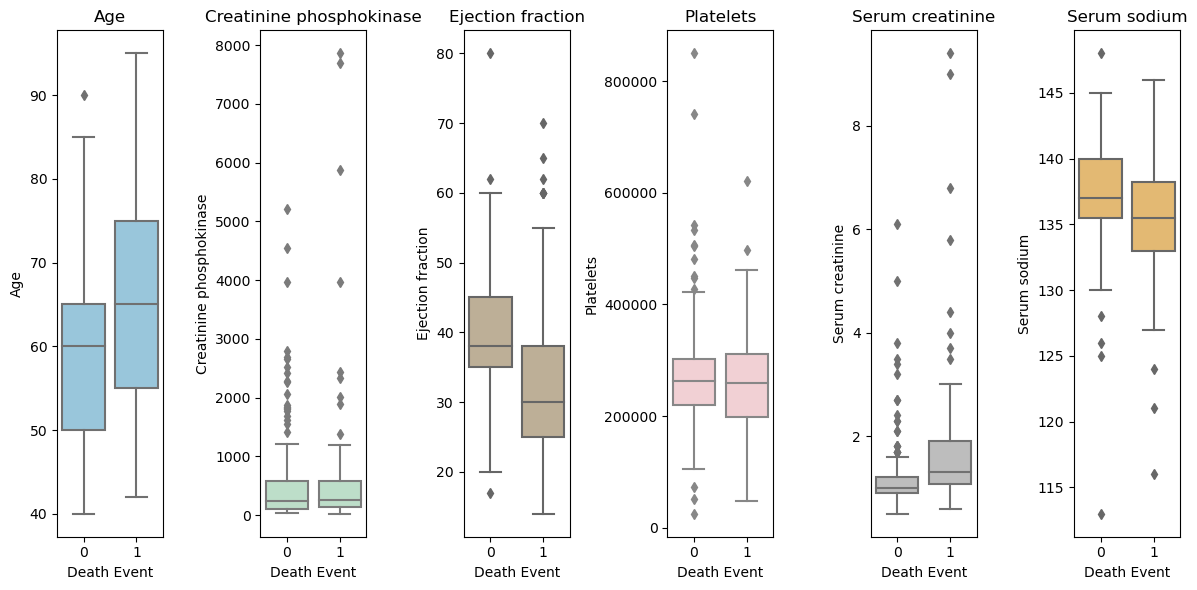

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of 6 numeric variables (excluding age)
numeric_vars = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
]

# Color palette for some visual variety
colors = ['#8ecae6', '#b7e4c7', '#c3b091', '#f7cad0', '#bdbdbd', '#f6bd60']

# Set up the plot grid
fig, axes = plt.subplots(1, 6, figsize=(12, 6), sharey=False)

for i, var in enumerate(numeric_vars):
    sns.boxplot(
        x='DEATH_EVENT',
        y=var,
        data=data,
        ax=axes[i],
        palette=[colors[i]],
        showfliers=True
    )
    axes[i].set_xlabel('Death Event')
    axes[i].set_ylabel(var.replace('_', ' ').capitalize())
    axes[i].set_title(var.replace('_', ' ').capitalize())
    axes[i].set_xticklabels(['0', '1'])

plt.tight_layout()
plt.show()


C:\Users\edmun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\edmun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\edmun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\edmun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

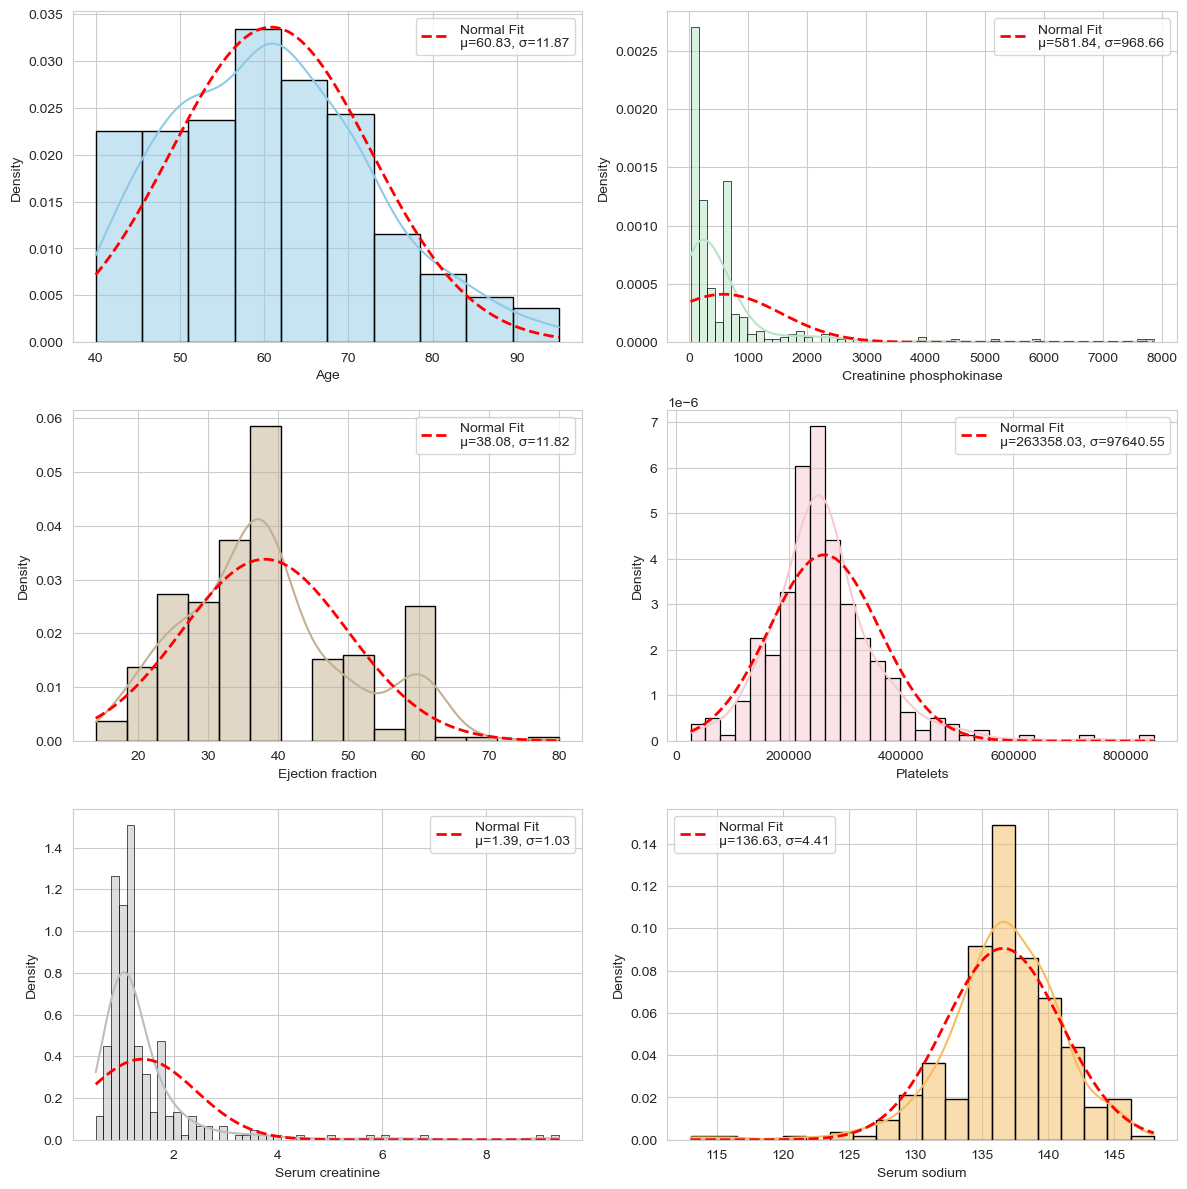

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Ensure seaborn style is applied
sns.set_style("whitegrid")

# Set up 3 rows × 2 columns figure
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    ax = axes[i]

    # Drop NaNs for the variable
    var_data = data[var].dropna()

    # Plot histogram + KDE
    sns.histplot(
        var_data, 
        kde=True, 
        stat="density", 
        color=colors[i], 
        edgecolor='black',
        ax=ax
    )

    # Fit a normal distribution and overlay
    mu, std = norm.fit(var_data)
    x = np.linspace(var_data.min(), var_data.max(), 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'r--', linewidth=2, label=f'Normal Fit\nμ={mu:.2f}, σ={std:.2f}')

    # Titles and labels
    #ax.set_title(var.replace('_', ' ').capitalize())
    ax.set_xlabel(var.replace('_', ' ').capitalize())
    ax.set_ylabel("Density")
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()

### Independent t-test and chi-square test of Independence

In [226]:
from scipy.stats import ttest_ind, chi2_contingency
# Variables
continuous_vars = [
    "age", "creatinine_phosphokinase", "ejection_fraction",
    "platelets", "serum_creatinine", "serum_sodium", "time"
]
categorical_vars = [
    "anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"
]

# Counts
n_total = data.shape[0]
n_alive = (data['DEATH_EVENT'] == 0).sum()
n_dead = (data['DEATH_EVENT'] == 1).sum()

# Continuous results
cont_rows = []
for var in continuous_vars:
    all_mean = data[var].mean()
    all_std = data[var].std()
    alive_mean = data[data['DEATH_EVENT']==0][var].mean()
    alive_std = data[data['DEATH_EVENT']==0][var].std()
    dead_mean = data[data['DEATH_EVENT']==1][var].mean()
    dead_std = data[data['DEATH_EVENT']==1][var].std()
    stat, p = ttest_ind(
        data[data['DEATH_EVENT']==1][var], 
        data[data['DEATH_EVENT']==0][var], 
        equal_var=False, 
        nan_policy='omit'
    )
    # Always show the actual p-value to four decimal places
    p_str = f"{p:.4f}"
    cont_rows.append([
        var.replace('_', ' ').title(),
        f"{all_mean:.2f} $\\pm$ {all_std:.2f}",
        f"{alive_mean:.2f} $\\pm$ {alive_std:.2f}",
        f"{dead_mean:.2f} $\\pm$ {dead_std:.2f}",
        p_str
    ])


# Categorical results
cat_rows = []
for var in categorical_vars:
    ct = pd.crosstab(data[var], data['DEATH_EVENT'])
    chi2, p, dof, exp = chi2_contingency(ct)
    # Always show the actual p-value to four decimal places
    p_str = f"{p:.4f}"
    rows = []
    for cat_val in ct.index:
        total = ct.loc[cat_val].sum()
        n_alive_cat = ct.loc[cat_val, 0] if 0 in ct.columns else 0
        n_dead_cat = ct.loc[cat_val, 1] if 1 in ct.columns else 0
        row = [
            f"{cat_val}",
            f"{total} ({100*total/n_total:.1f})",
            f"{n_alive_cat} ({100*n_alive_cat/n_alive:.1f})",
            f"{n_dead_cat} ({100*n_dead_cat/n_dead:.1f})"
        ]
        rows.append(row)
    cat_rows.append([var.replace('_', ' ').title(), rows, p_str])

cont_rows, cat_rows, n_total, n_alive, n_dead

([['Age',
   '60.83 $\\pm$ 11.89',
   '58.76 $\\pm$ 10.64',
   '65.22 $\\pm$ 13.21',
   '0.0000'],
  ['Creatinine Phosphokinase',
   '581.84 $\\pm$ 970.29',
   '540.05 $\\pm$ 753.80',
   '670.20 $\\pm$ 1316.58',
   '0.3692'],
  ['Ejection Fraction',
   '38.08 $\\pm$ 11.83',
   '40.27 $\\pm$ 10.86',
   '33.47 $\\pm$ 12.53',
   '0.0000'],
  ['Platelets',
   '263358.03 $\\pm$ 97804.24',
   '266657.49 $\\pm$ 97531.20',
   '256381.04 $\\pm$ 98525.68',
   '0.3993'],
  ['Serum Creatinine',
   '1.39 $\\pm$ 1.03',
   '1.18 $\\pm$ 0.65',
   '1.84 $\\pm$ 1.47',
   '0.0001'],
  ['Serum Sodium',
   '136.63 $\\pm$ 4.41',
   '137.22 $\\pm$ 3.98',
   '135.38 $\\pm$ 5.00',
   '0.0019'],
  ['Time',
   '130.26 $\\pm$ 77.61',
   '158.34 $\\pm$ 67.74',
   '70.89 $\\pm$ 62.38',
   '0.0000']],
 [['Anaemia',
   [['0', '170 (56.9)', '120 (59.1)', '50 (52.1)'],
    ['1', '129 (43.1)', '83 (40.9)', '46 (47.9)']],
   '0.3073'],
  ['Diabetes',
   [['0', '174 (58.2)', '118 (58.1)', '56 (58.3)'],
    ['1', '125 (41.

In [17]:
# Define features and target
X = data.drop(['DEATH_EVENT'], axis=1)
y = data['DEATH_EVENT']
feature_names = X.columns

In [19]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
def needs_scaling(model):
    return isinstance(model, (LogisticRegression,RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier,AdaBoostClassifier,SVC,XGBClassifier,LGBMClassifier,CatBoostClassifier))

In [27]:
# Define models 
classification_models = {
    "Logistic_Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "Random_Forest_Clf": RandomForestClassifier(random_state=42),
    "Extra_Trees_Clf": ExtraTreesClassifier(random_state=42),  # <--- Extra Trees added!
    "Gradient_Boosting_Clf": GradientBoostingClassifier(random_state=42),  # sklearn's
    "AdaBoost_Clf": AdaBoostClassifier(random_state=42),
    "SVC_Clf": SVC(probability=True, random_state=42),
    "XGBoost_Clf": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM_Clf": LGBMClassifier(random_state=42),
    "CatBoost_Clf": CatBoostClassifier(random_state=42, verbose=0)  # Optional, only if installed
}

In [37]:
param_grids = {
    "Logistic_Regression": {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'class_weight': ['balanced']
    },
    "Random_Forest_Clf": {
        'n_estimators': [50, 100],
        'max_depth': [2, 3],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [4, 8, 12]
    },
    "Extra_Trees_Clf": {
        'n_estimators': [50, 100],
        'max_depth': [None, 3, 5],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 4, 8]
    },
    "Gradient_Boosting_Clf": {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.05],
        'max_depth': [2, 3],
        'subsample': [0.8, 1.0],
        'min_samples_leaf': [4, 8, 12]
    },
    "AdaBoost_Clf": {
        'n_estimators': [50, 100, 200],  # Trying a higher value too
        'learning_rate': [0.001, 0.01, 0.1, 1.0],  # Finer and wider range
        'algorithm': ['SAMME', 'SAMME.R']  # Try both algorithms
    },
    "SVC_Clf": {
        'C': [0.01, 0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto'],
        'class_weight': [None, 'balanced']
    },
    "XGBoost_Clf": {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    "LightGBM_Clf": {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 5],
        'num_leaves': [7, 15, 31],
        'subsample': [0.8, 1.0]
    },
    "CatBoost_Clf": {
        'iterations': [50, 100],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [3, 5, 7],
        'l2_leaf_reg': [1, 3, 5]
    }
}

In [39]:
# Hyperparameter tuning with GridSearchCV
best_classification_models = {}

for name, model in classification_models.items():
    print(f"\n🔍 Tuning {name}...")
    X_used_train = X_train_scaled if needs_scaling(model) else X_train
    grid = param_grids.get(name, {})
    if grid:
        search = GridSearchCV(model, grid, cv=5, scoring='accuracy', n_jobs=-1)
        search.fit(X_used_train, y_train)
        best_model = search.best_estimator_
        print(f"Best params: {search.best_params_}")
    else:
        model.fit(X_used_train, y_train)
        best_model = model
        print("No hyperparameters to tune.")
    best_classification_models[name] = best_model


🔍 Tuning Logistic_Regression...
Best params: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

🔍 Tuning Random_Forest_Clf...
Best params: {'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 100}

🔍 Tuning Extra_Trees_Clf...
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

🔍 Tuning Gradient_Boosting_Clf...
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 8, 'n_estimators': 50, 'subsample': 0.8}

🔍 Tuning AdaBoost_Clf...


C:\Users\edmun\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best params: {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 50}

🔍 Tuning SVC_Clf...
Best params: {'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}

🔍 Tuning XGBoost_Clf...
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}

🔍 Tuning LightGBM_Clf...
[LightGBM] [Info] Number of positive: 71, number of negative: 168
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 302
[LightGBM] [Info] Number of data points in the train set: 239, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.297071 -> initscore=-0.861284
[LightGBM] [Info] Start training from score -0.861284
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

In [41]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, 
    balanced_accuracy_score, matthews_corrcoef
)
from sklearn.model_selection import cross_val_score

# Evaluation for classifiers
def evaluate_classifier(model, name):
    X_used_train = X_train_scaled if needs_scaling(model) else X_train
    X_used_test = X_test_scaled if needs_scaling(model) else X_test

    scores = cross_val_score(model, X_used_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_used_train, y_train)

    y_train_pred = model.predict(X_used_train)
    y_test_pred = model.predict(X_used_test)
    y_test_proba = model.predict_proba(X_used_test)[:,1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Train_Balanced_Accuracy': balanced_accuracy_score(y_train, y_train_pred),
        'Test_Balanced_Accuracy': balanced_accuracy_score(y_test, y_test_pred),
        'Train_MCC': matthews_corrcoef(y_train, y_train_pred),
        'Test_MCC': matthews_corrcoef(y_test, y_test_pred),
        'Train_F1': f1_score(y_train, y_train_pred),
        'Test_F1': f1_score(y_test, y_test_pred),
        'Test_ROC_AUC': roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else np.nan,
        'Train_Precision': precision_score(y_train, y_train_pred),
        'Test_Precision': precision_score(y_test, y_test_pred),
        'Train_Recall': recall_score(y_train, y_train_pred),
        'Test_Recall': recall_score(y_test, y_test_pred),
        'CV_Accuracy_Mean': scores.mean(),
        'CV_Accuracy_STD': scores.std(),
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba
    }

    print(f"\n📊 Classifier: {name}")
    for k, v in metrics.items():
        if k not in ['y_test_pred', 'y_test_proba']:
            print(f"{k}: {v:.4f}")

    return metrics

In [43]:
# Collect metrics
classification_metrics = {name: evaluate_classifier(model, name) for name, model in best_classification_models.items()}


📊 Classifier: Logistic_Regression
Train_Accuracy: 0.8410
Test_Accuracy: 0.8000
Train_Balanced_Accuracy: 0.8462
Test_Balanced_Accuracy: 0.7771
Train_MCC: 0.6546
Test_MCC: 0.5874
Train_F1: 0.7625
Test_F1: 0.7273
Test_ROC_AUC: 0.8389
Train_Precision: 0.6854
Test_Precision: 0.8421
Train_Recall: 0.8592
Test_Recall: 0.6400
CV_Accuracy_Mean: 0.8201
CV_Accuracy_STD: 0.0361

📊 Classifier: Random_Forest_Clf
Train_Accuracy: 0.9079
Test_Accuracy: 0.7500
Train_Balanced_Accuracy: 0.8695
Test_Balanced_Accuracy: 0.7114
Train_MCC: 0.7745
Test_MCC: 0.4929
Train_F1: 0.8333
Test_F1: 0.6154
Test_ROC_AUC: 0.8537
Train_Precision: 0.9016
Test_Precision: 0.8571
Train_Recall: 0.7746
Test_Recall: 0.4800
CV_Accuracy_Mean: 0.8830
CV_Accuracy_STD: 0.0484

📊 Classifier: Extra_Trees_Clf
Train_Accuracy: 0.9623
Test_Accuracy: 0.7167
Train_Balanced_Accuracy: 0.9488
Test_Balanced_Accuracy: 0.6657
Train_MCC: 0.9091
Test_MCC: 0.4384
Train_F1: 0.9353
Test_F1: 0.5143
Test_ROC_AUC: 0.8343
Train_Precision: 0.9559
Test_Precisi

C:\Users\edmun\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\edmun\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\edmun\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\edmun\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\edm


📊 Classifier: AdaBoost_Clf
Train_Accuracy: 0.8996
Test_Accuracy: 0.7500
Train_Balanced_Accuracy: 0.8513
Test_Balanced_Accuracy: 0.7057
Train_MCC: 0.7534
Test_MCC: 0.5071
Train_F1: 0.8125
Test_F1: 0.5946
Test_ROC_AUC: 0.8589
Train_Precision: 0.9123
Test_Precision: 0.9167
Train_Recall: 0.7324
Test_Recall: 0.4400
CV_Accuracy_Mean: 0.8746
CV_Accuracy_STD: 0.0434

📊 Classifier: SVC_Clf
Train_Accuracy: 0.8745
Test_Accuracy: 0.8000
Train_Balanced_Accuracy: 0.8457
Test_Balanced_Accuracy: 0.7714
Train_MCC: 0.6971
Test_MCC: 0.5939
Train_F1: 0.7857
Test_F1: 0.7143
Test_ROC_AUC: 0.8309
Train_Precision: 0.7971
Test_Precision: 0.8824
Train_Recall: 0.7746
Test_Recall: 0.6000
CV_Accuracy_Mean: 0.8241
CV_Accuracy_STD: 0.0510

📊 Classifier: XGBoost_Clf
Train_Accuracy: 0.9372
Test_Accuracy: 0.7333
Train_Balanced_Accuracy: 0.9106
Test_Balanced_Accuracy: 0.7029
Train_MCC: 0.8475
Test_MCC: 0.4439
Train_F1: 0.8889
Test_F1: 0.6190
Test_ROC_AUC: 0.8674
Train_Precision: 0.9375
Test_Precision: 0.7647
Train_Reca

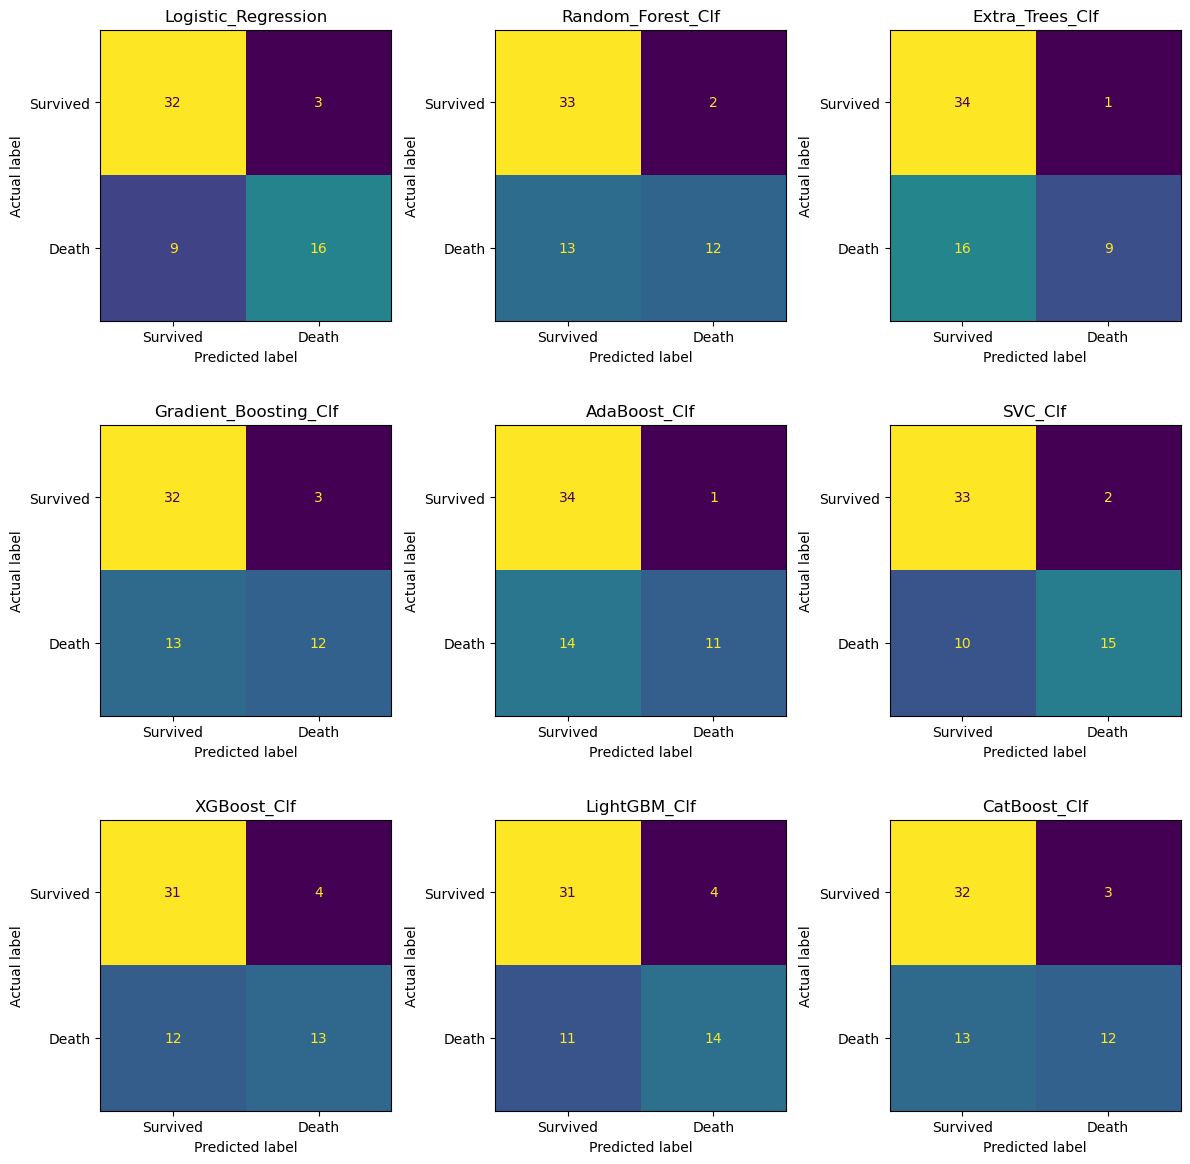

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['Survived', 'Death']

plt.figure(figsize=(12, 12))
for idx, (name, metrics) in enumerate(classification_metrics.items()):
    plt.subplot(3, 3, idx+1)
    cm = confusion_matrix(y_test, metrics['y_test_pred'], labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=plt.gca(), colorbar=False)
    plt.title(name)
    plt.xlabel('Predicted label')
    plt.ylabel('Actual label')
plt.tight_layout()
plt.show()

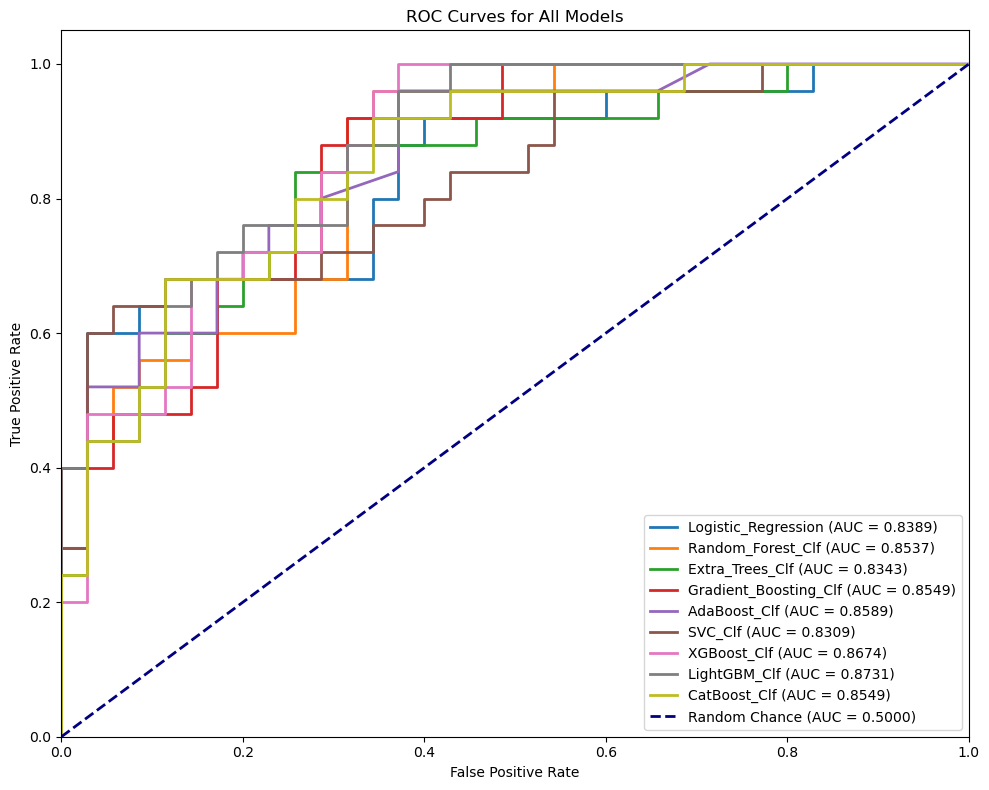

In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for name, metrics in classification_metrics.items():
    y_test_proba = metrics['y_test_proba']
    if y_test_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
# Add the random chance (diagonal) line with legend
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

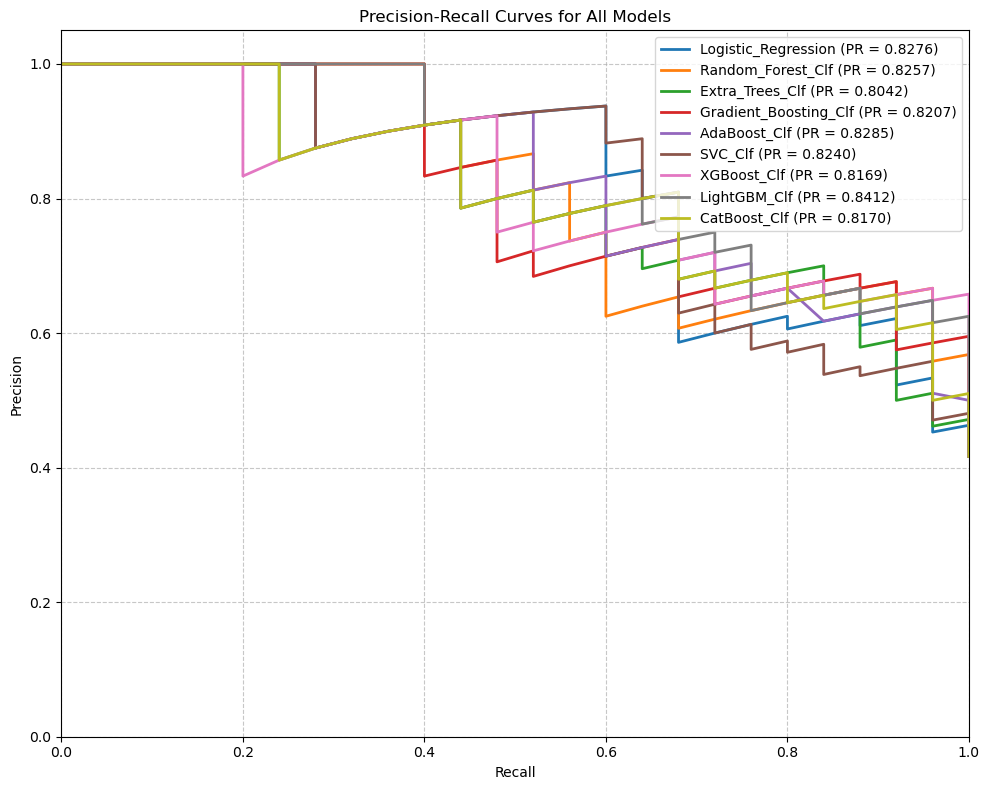

In [55]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for name, metrics in classification_metrics.items():
    y_test_proba = metrics['y_test_proba']
    if y_test_proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
        avg_prec = average_precision_score(y_test, y_test_proba)
        plt.plot(
            recall, precision, lw=2,
            label=f'{name} (PR = {avg_prec:.4f})'
        )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for All Models')
plt.legend(loc="upper right")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [450]:
# Save metrics to CSV
#clf_df.drop(columns=['y_test_pred', 'y_test_proba'], errors='ignore').to_csv('classification_metrics.csv')
#print("✅ Metrics saved to 'classification_metrics.csv'")

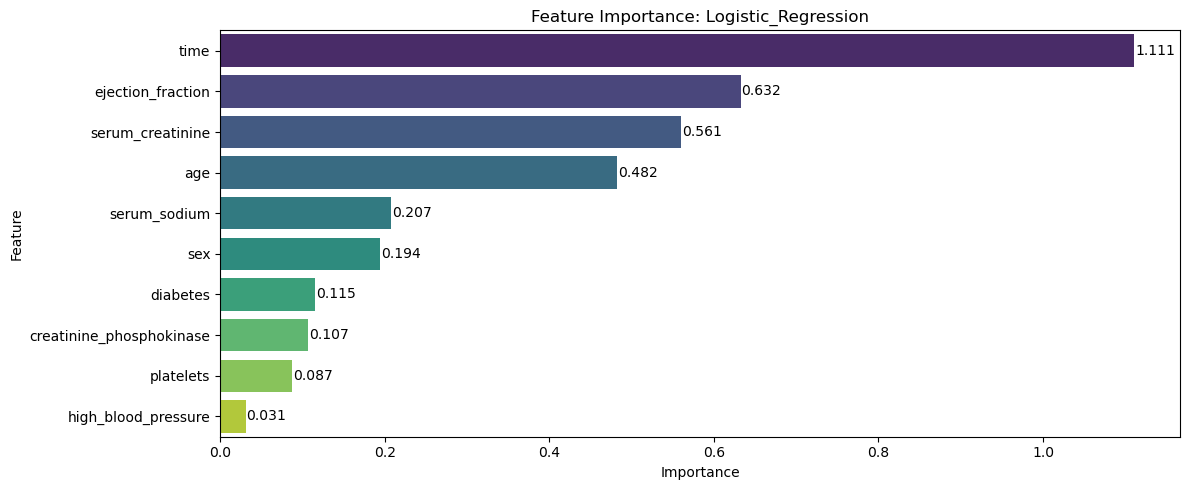

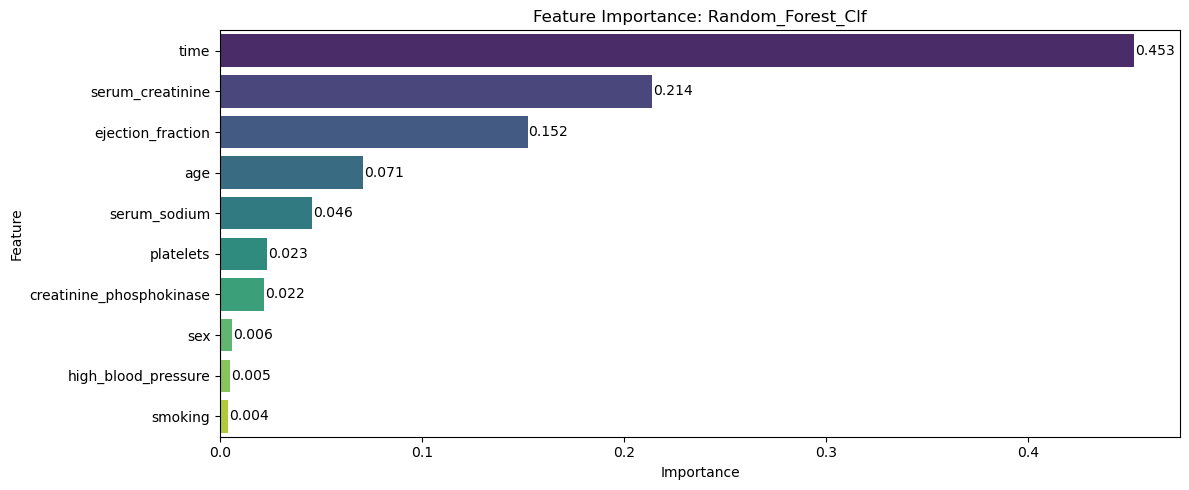

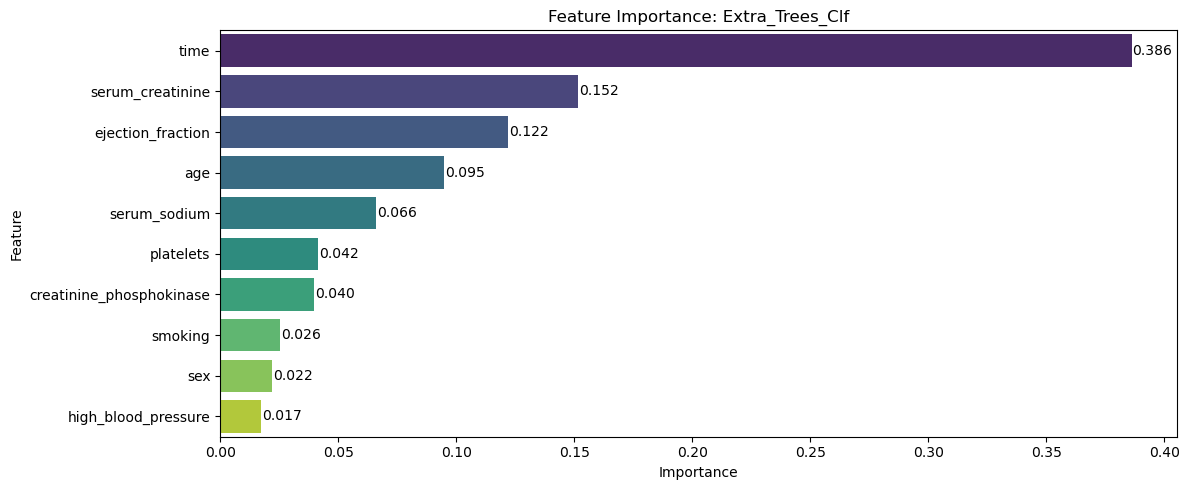

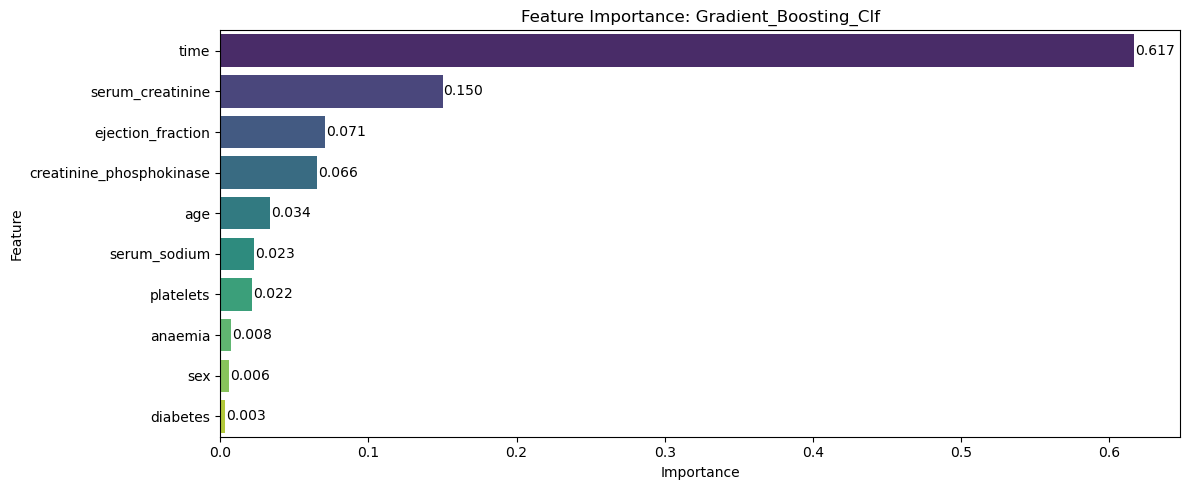

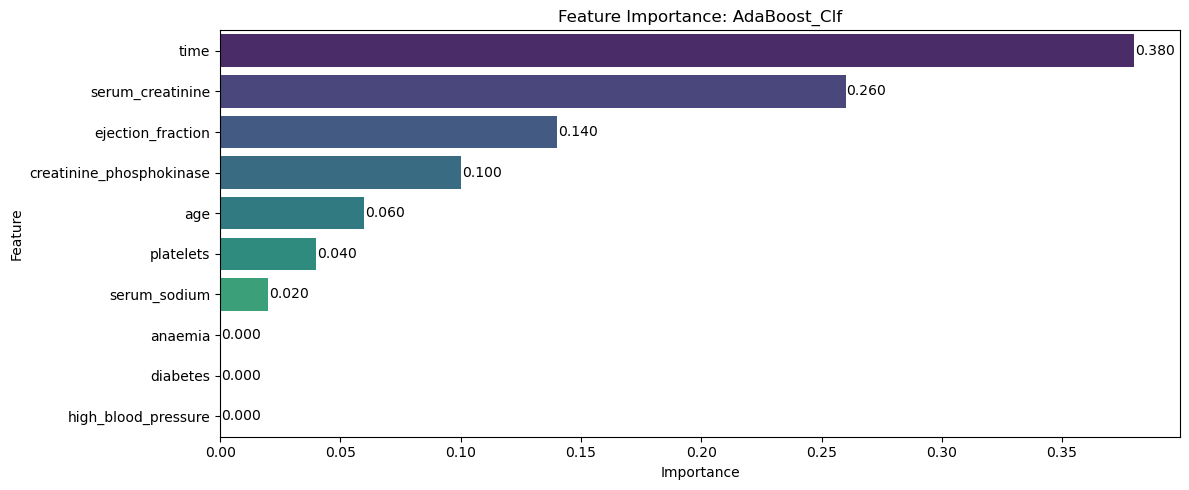

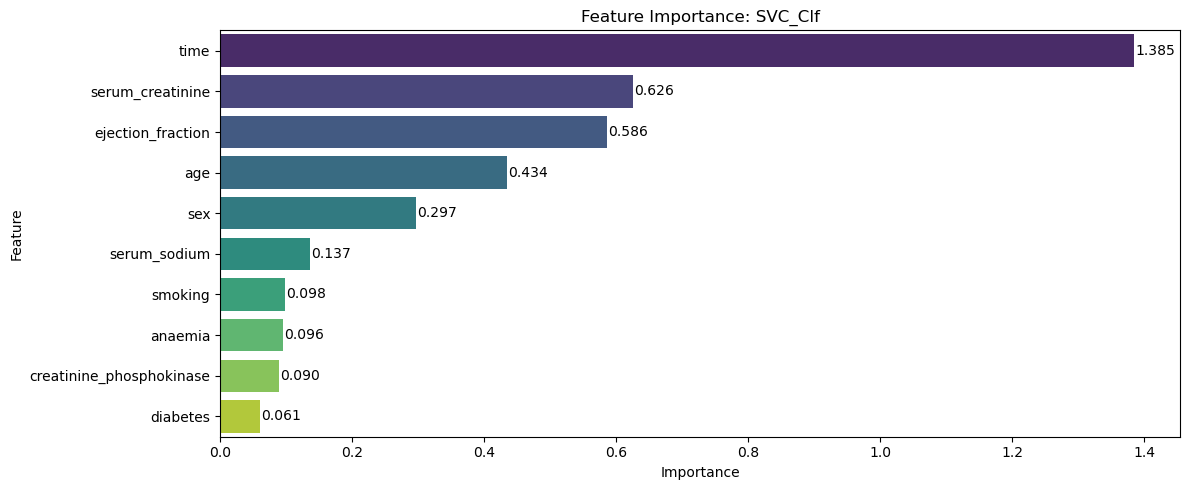

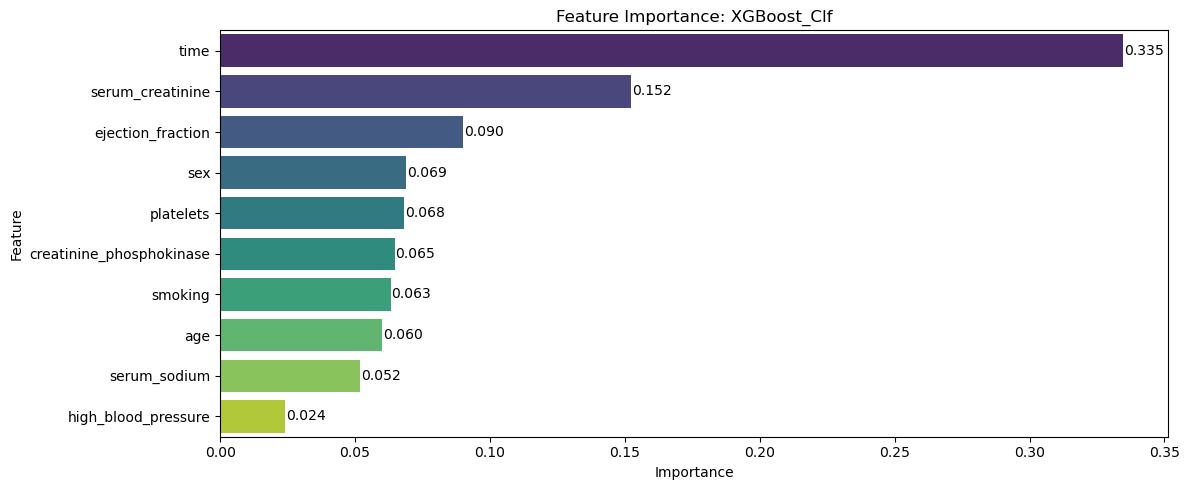

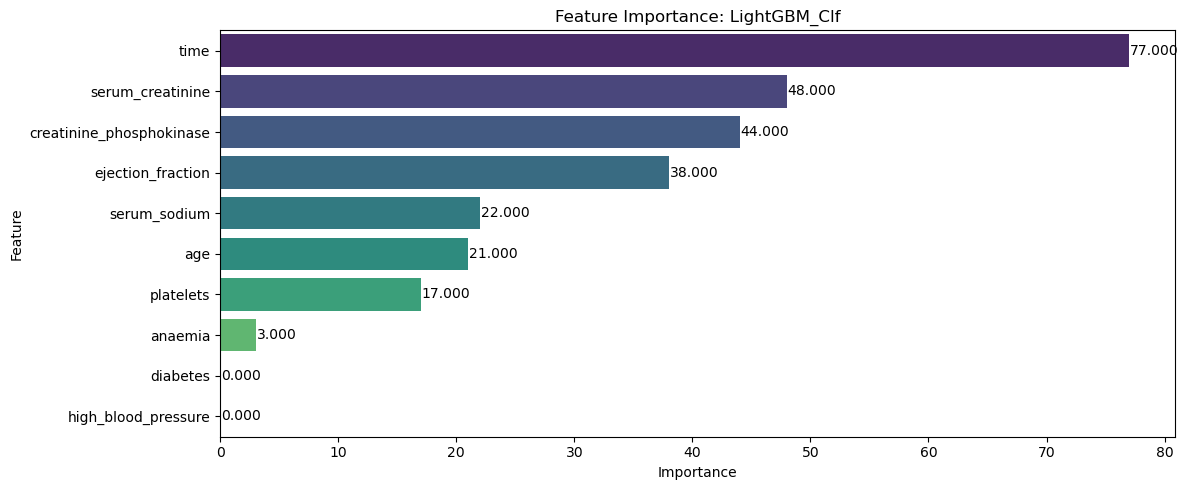

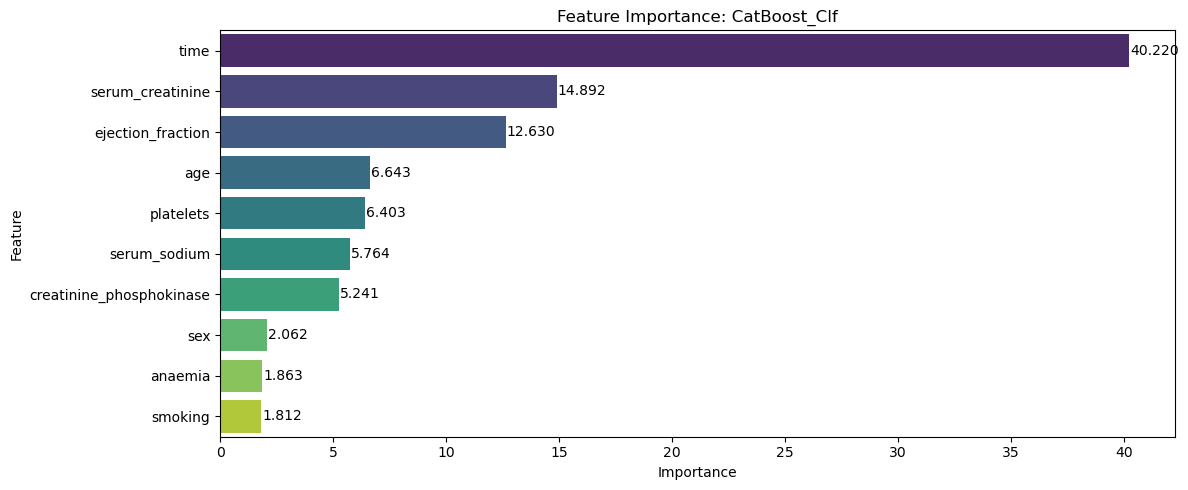

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, name):
    try:
        importances = model.feature_importances_
    except AttributeError:
        try:
            importances = model.coef_[0] if len(model.coef_.shape) > 1 else model.coef_
        except:
            print(f"⚠️ No feature importance for {name}")
            return
    
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(importances)})
    importance_df.sort_values('Importance', ascending=False, inplace=True)
    top_n = importance_df.head(10)
    
    plt.figure(figsize=(12, 5))
    ax = sns.barplot(x='Importance', y='Feature', data=top_n, palette="viridis")
    plt.title(f'Feature Importance: {name}')

    # Annotate each bar with its importance value
    for i, (importance, feature) in enumerate(zip(top_n['Importance'], top_n['Feature'])):
        ax.text(importance + 0.001 * top_n['Importance'].max(), i, 
                f"{importance:.3f}", 
                va='center', ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()

for name, model in best_classification_models.items():
    plot_feature_importance(model, name)

### SHAP Analysis

In [453]:
model_xgb = XGBClassifier(colsample_bytree=1.0, learning_rate=0.1, max_depth=2, n_estimators=50, subsample=0.8)
model_xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

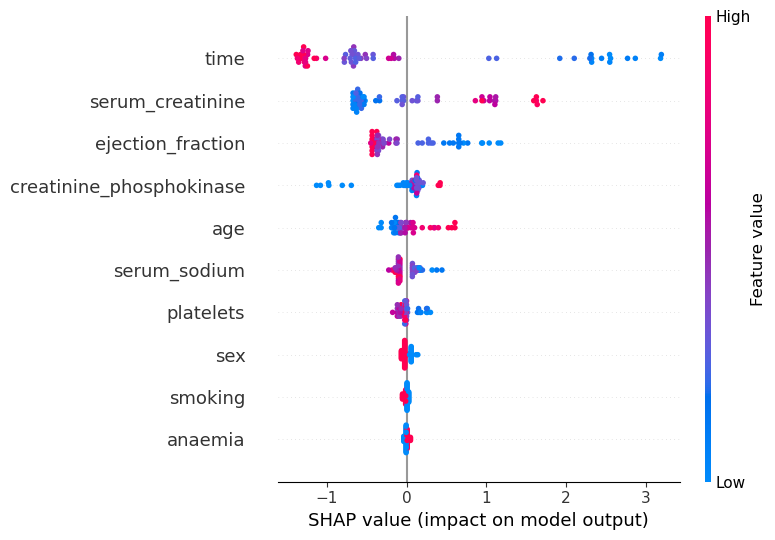

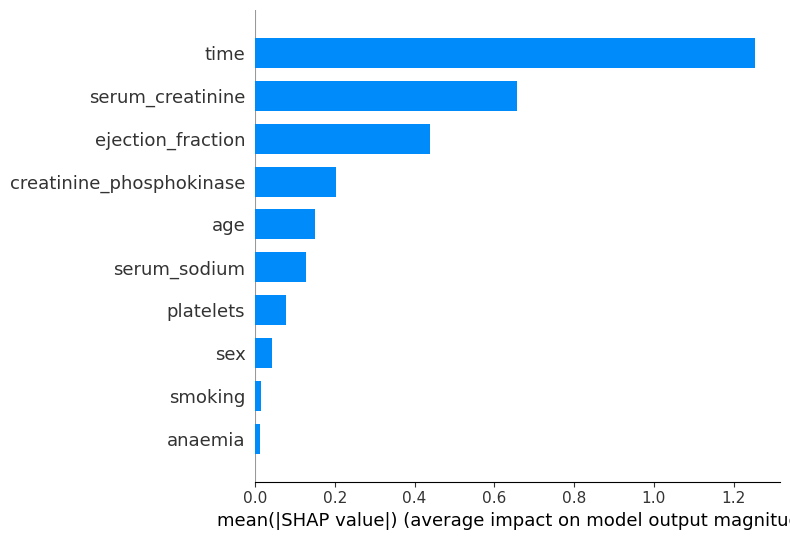

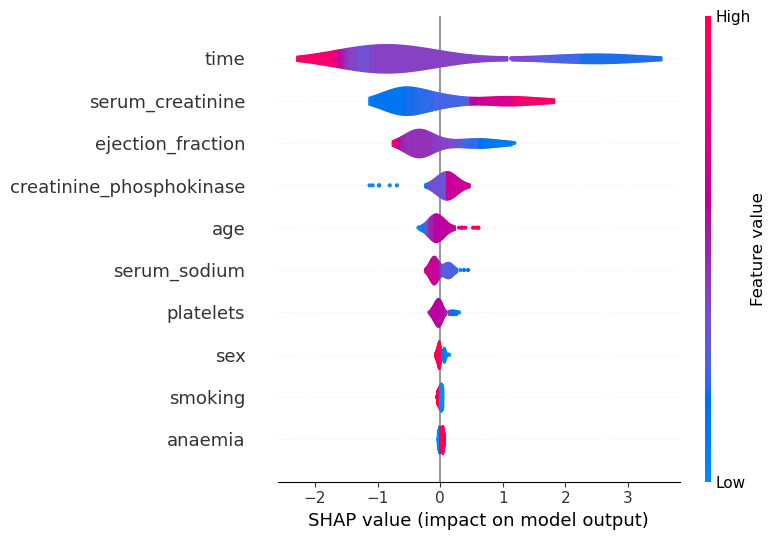

In [454]:
import shap

# SHAP explainer using TreeExplainer (best for tree-based models)
explainer = shap.Explainer(model_xgb, X_test_scaled)
shap_values = explainer(X_test_scaled,check_additivity=False)

# Beeswarm plot: only show top 10 features
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, max_display=10)

# Bar plot: only show top 10 features
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, plot_type="bar", max_display=10)

# Violin plot
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, plot_type='violin', max_display=10)

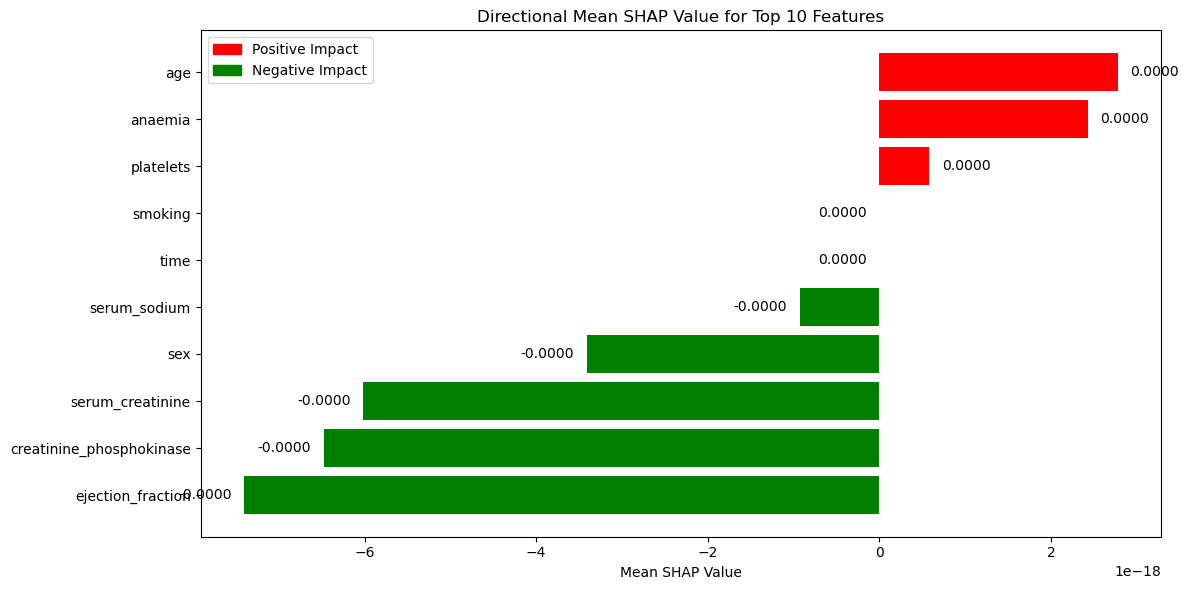

In [455]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Convert SHAP values to a DataFrame
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)

# 2. Compute mean and mean absolute SHAP values for each feature
mean_shap = shap_df.mean(axis=0)
mean_abs_shap = shap_df.abs().mean(axis=0)

# 3. Select top 10 features by mean absolute SHAP
top_features = mean_abs_shap.nlargest(10).index.tolist()

# 4. Build plot DataFrame (guaranteed to have only 10 features)
plot_df = pd.DataFrame({
    'feature': top_features,
    'mean_shap': mean_shap[top_features].values
}).sort_values('mean_shap', ascending=True)  # ascending for barh

# 5. Assign color: red for positive, green for negative mean SHAP
colors = ['red' if val > 0 else 'green' for val in plot_df['mean_shap']]

# 6. Plot the horizontal bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(plot_df['feature'], plot_df['mean_shap'], color=colors)
plt.xlabel("Mean SHAP Value")
plt.title("Directional Mean SHAP Value for Top 10 Features")

# 7. Add value labels to each bar at the end of the bar
# Offset value (a small shift so text isn't on top of the bar edge)
offset = 0.02 * plot_df['mean_shap'].abs().max()  # 2% of max SHAP value for space

for bar in bars:
    xval = bar.get_width()
    yval = bar.get_y() + bar.get_height() / 2
    # If bar is positive, put label to the right; if negative, to the left
    ha = 'left' if xval > 0 else 'right'
    plt.text(
        xval + (offset if xval > 0 else -offset),
        yval,
        f"{xval:.4f}",
        va='center',
        ha=ha,
        fontsize=10,
        color='black'
)

# 8. Add a custom legend
legend_handles = [
    Patch(color='red', label='Positive Impact'),
    Patch(color='green', label='Negative Impact')
]
plt.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.show()

In [456]:
model_gb = GradientBoostingClassifier(learning_rate=0.05, max_depth=3, min_samples_leaf=8, n_estimators=50, subsample=0.8)
model_gb.fit(X_train_scaled, y_train)

GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=8,
                           n_estimators=50, subsample=0.8)

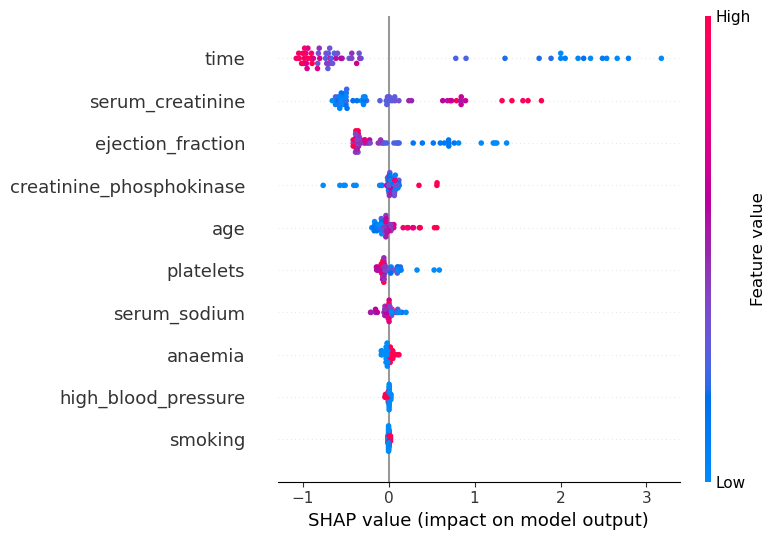

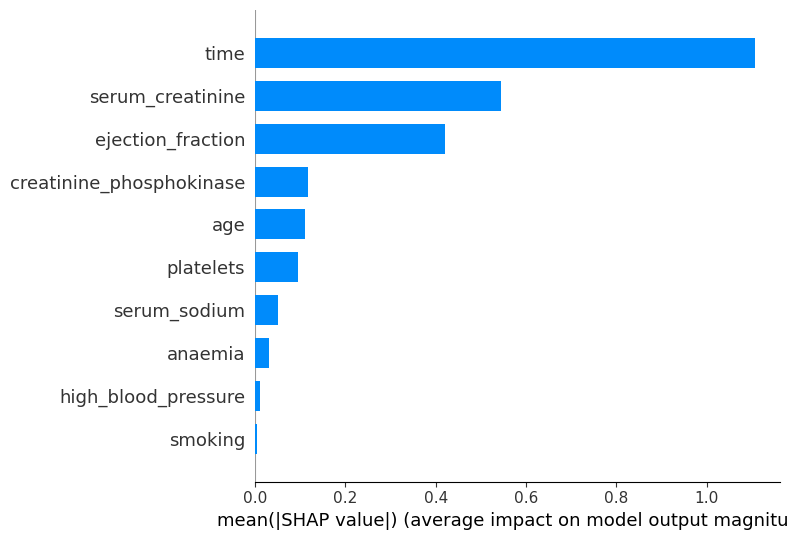

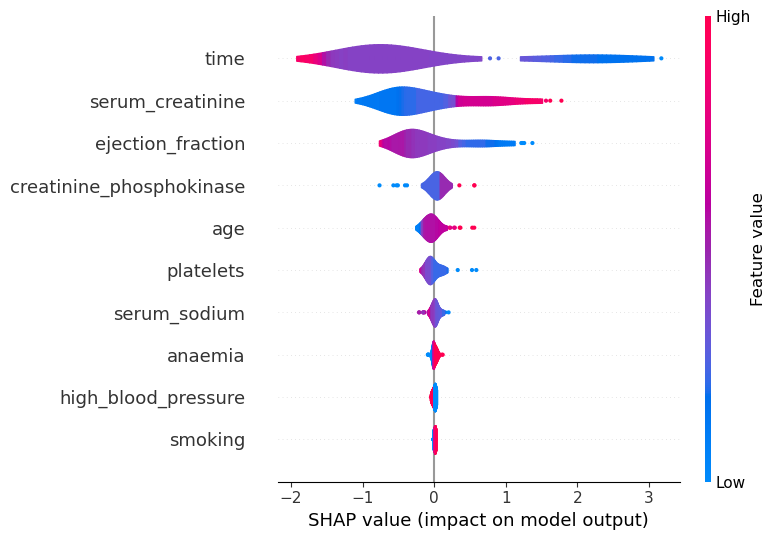

In [457]:
import shap

# SHAP explainer using TreeExplainer (best for tree-based models)
explainer = shap.Explainer(model_gb, X_test_scaled)
shap_values = explainer(X_test_scaled,check_additivity=False)

# Beeswarm plot: only show top 10 features
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, max_display=10)

# Bar plot: only show top 10 features
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, plot_type="bar", max_display=10)

# Violin plot
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, plot_type='violin', max_display=10)

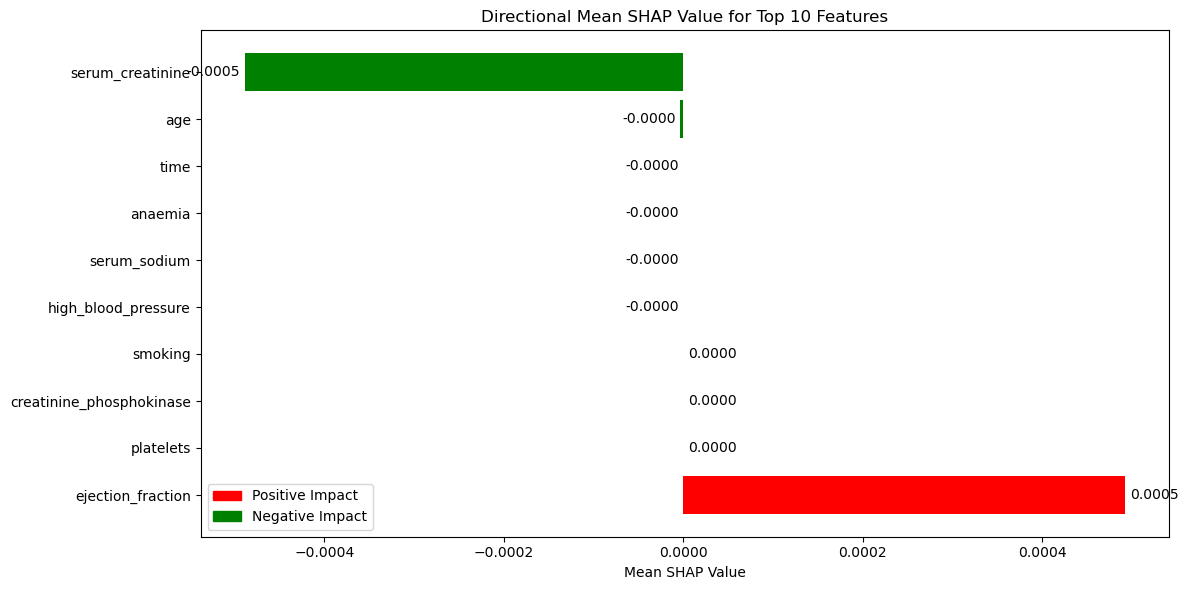

In [458]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Convert SHAP values to a DataFrame
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)

# 2. Compute mean and mean absolute SHAP values for each feature
mean_shap = shap_df.mean(axis=0)
mean_abs_shap = shap_df.abs().mean(axis=0)

# 3. Select top 10 features by mean absolute SHAP
top_features = mean_abs_shap.nlargest(10).index.tolist()

# 4. Build plot DataFrame (guaranteed to have only 10 features)
plot_df = pd.DataFrame({
    'feature': top_features,
    'mean_shap': mean_shap[top_features].values
}).sort_values('mean_shap', ascending=False)  # ascending for barh

# 5. Assign color: red for positive, green for negative mean SHAP
colors = ['red' if val > 0 else 'green' for val in plot_df['mean_shap']]

# 6. Plot the horizontal bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(plot_df['feature'], plot_df['mean_shap'], color=colors)
plt.xlabel("Mean SHAP Value")
plt.title("Directional Mean SHAP Value for Top 10 Features")

# 7. Add value labels to each bar at the end of the bar
# Offset value (a small shift so text isn't on top of the bar edge)
offset = 0.01 * plot_df['mean_shap'].abs().max()  # 2% of max SHAP value for space

for bar in bars:
    xval = bar.get_width()
    yval = bar.get_y() + bar.get_height() / 2
    # If bar is positive, put label to the right; if negative, to the left
    ha = 'left' if xval > 0 else 'right'
    plt.text(
        xval + (offset if xval > 0 else -offset),
        yval,
        f"{xval:.4f}",
        va='center',
        ha=ha,
        fontsize=10,
        color='black'
    )

# 8. Add a custom legend
legend_handles = [
    Patch(color='red', label='Positive Impact'),
    Patch(color='green', label='Negative Impact')
]
plt.legend(handles=legend_handles, loc='lower left')

plt.tight_layout()
plt.show()

### SHAP Analysis (LightGBM)

In [117]:
model_lgb = LGBMClassifier(learning_rate=0.05, max_depth=2, min_samples_leaf=8, n_estimators=100, num_leaves= 7,subsample=0.8)
model_lgb.fit(X_train_scaled, y_train)

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=8. Current value: min_data_in_leaf=8
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=8. Current value: min_data_in_leaf=8
[LightGBM] [Info] Number of positive: 71, number of negative: 168
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 302
[LightGBM] [Info] Number of data points in the train set: 239, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.297071 -> initscore=-0.861284
[LightGBM] [Info] Start training from score -0.861284
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMClassifier(learning_rate=0.05, max_depth=2, min_samples_leaf=8,
               num_leaves=7, subsample=0.8)

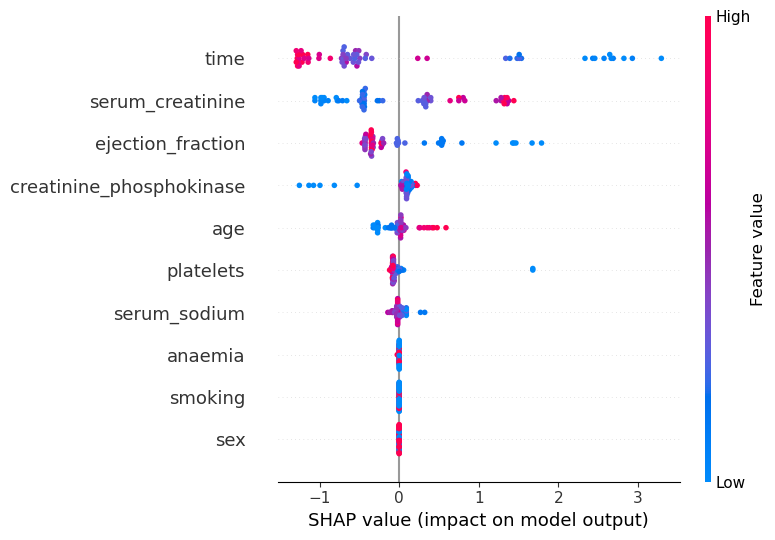

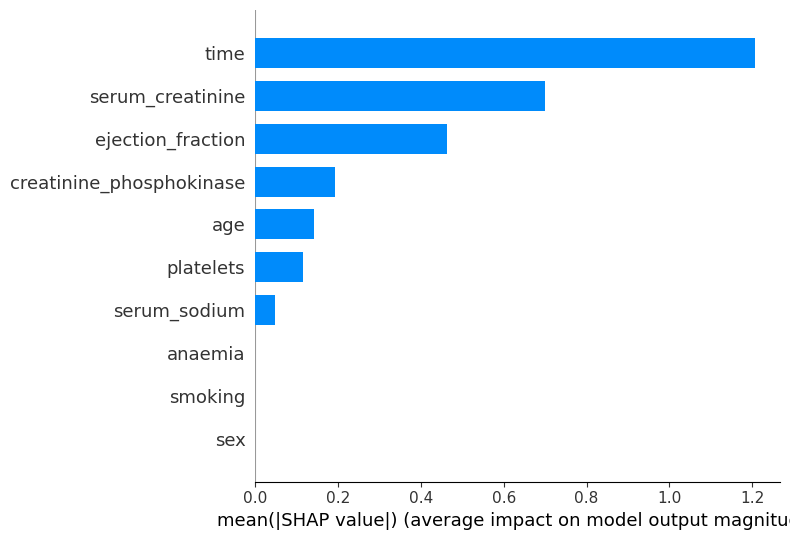

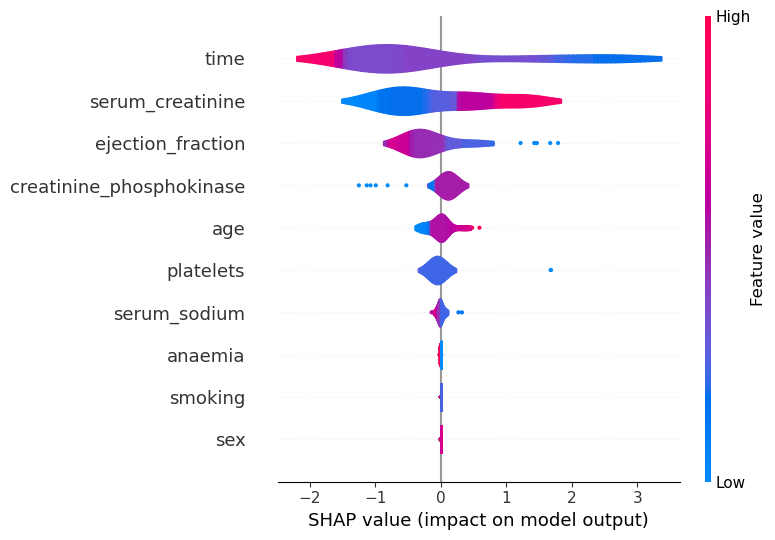

In [119]:
import shap
# SHAP explainer using TreeExplainer (best for tree-based models)
explainer = shap.Explainer(model_lgb, X_test_scaled)
shap_values = explainer(X_test_scaled,check_additivity=False)

# Beeswarm plot: only show top 10 features
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, max_display=10)

# Bar plot: only show top 10 features
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, plot_type="bar", max_display=10)

# Violin plot
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns, plot_type='violin', max_display=10)

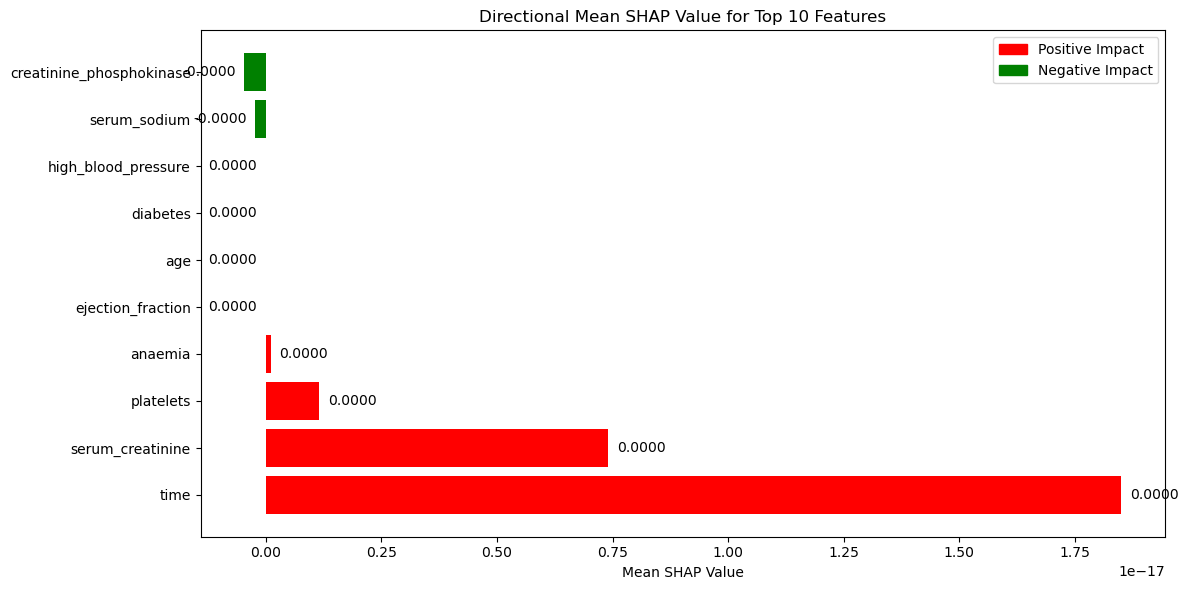

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Convert SHAP values to a DataFrame
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)

# 2. Compute mean and mean absolute SHAP values for each feature
mean_shap = shap_df.mean(axis=0)
mean_abs_shap = shap_df.abs().mean(axis=0)

# 3. Select top 10 features by mean absolute SHAP
top_features = mean_abs_shap.nlargest(10).index.tolist()

# 4. Build plot DataFrame (guaranteed to have only 10 features)
plot_df = pd.DataFrame({
    'feature': top_features,
    'mean_shap': mean_shap[top_features].values
}).sort_values('mean_shap', ascending=False)  # ascending for barh

# 5. Assign color: red for positive, green for negative mean SHAP
colors = ['red' if val > 0 else 'green' for val in plot_df['mean_shap']]

# 6. Plot the horizontal bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(plot_df['feature'], plot_df['mean_shap'], color=colors)
plt.xlabel("Mean SHAP Value")
plt.title("Directional Mean SHAP Value for Top 10 Features")

# 7. Add value labels to each bar at the end of the bar
# Offset value (a small shift so text isn't on top of the bar edge)
offset = 0.01 * plot_df['mean_shap'].abs().max()  # 2% of max SHAP value for space

for bar in bars:
    xval = bar.get_width()
    yval = bar.get_y() + bar.get_height() / 2
    # If bar is positive, put label to the right; if negative, to the left
    ha = 'left' if xval > 0 else 'right'
    plt.text(
        xval + (offset if xval > 0 else -offset),
        yval,
        f"{xval:.4f}",
        va='center',
        ha=ha,
        fontsize=10,
        color='black'
    )

# 8. Add a custom legend
legend_handles = [
    Patch(color='red', label='Positive Impact'),
    Patch(color='green', label='Negative Impact')
]
plt.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

# Performance Evaluation Plot

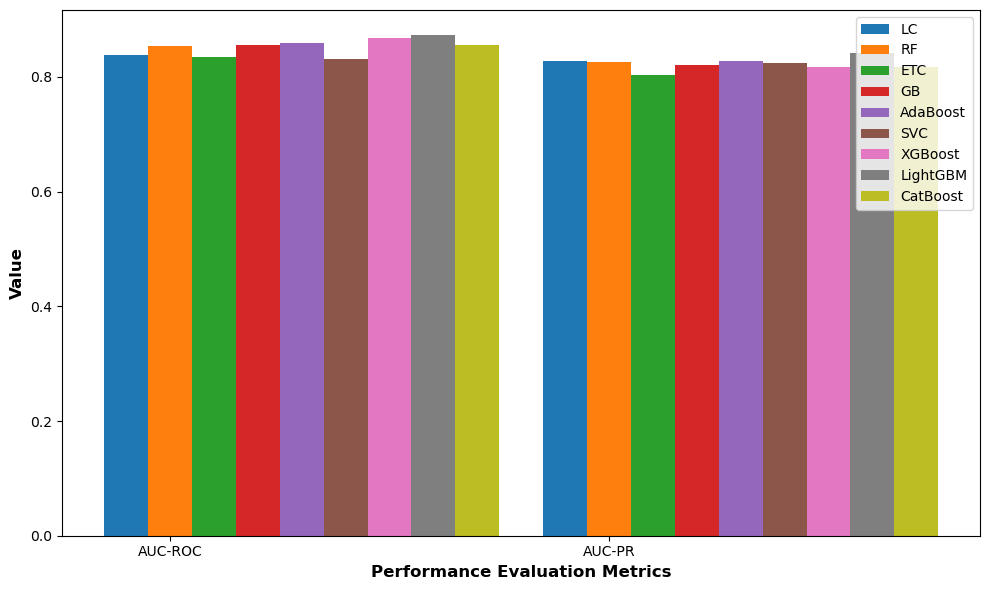

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Models': ['LC', 'RF', 'ETC','GB','AdaBoost','SVC','XGBoost','LightGBM','CatBoost'],
    'AUC-ROC': [0.8389, 0.8537,0.8343,0.8549,0.8589,0.8309,0.8674,0.8731,0.8549],
    'AUC-PR': [0.8276,0.8257,0.8042,0.8207,0.8285,0.8240,0.8169,0.8412,0.8170]
}

df = pd.DataFrame(data)


# Selecting the columns to plot
metrics_to_plot = ['AUC-ROC', 'AUC-PR']
models = df['Models']
values = df[metrics_to_plot]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))


# Set the position of the bars on the x-axis
bar_positions = list(range(len(metrics_to_plot)))

# The width of a bar
bar_width = 0.10

# Setting the position of the grouped bars
model_positions = [bar_positions]
for i in range(1, len(models)):
    model_positions.append([x + bar_width for x in model_positions[i-1]])

# Plotting each set of bars for each model
for i, model in enumerate(models):
    plt.bar(model_positions[i], df.loc[df['Models'] == model, metrics_to_plot].values.flatten(),
            width=bar_width, label=model)

# Adding labels and title
plt.xlabel('Performance Evaluation Metrics', fontweight='bold', fontsize=12)
plt.ylabel('Value', fontweight='bold', fontsize=12)

# Adding the xticks, with a slight adjustment in position to centre them
plt.xticks([r + bar_width for r in range(len(metrics_to_plot))], metrics_to_plot)

# Adding the legend and showing the plot
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance Analysis

In [25]:
import pandas as pd
import numpy as np

df = pd.DataFrame(
    {
        "AdaBoost_Clf": {
            "time": 0.380,
            "serum_creatinine": 0.260,
            "ejection_fraction": 0.140,
            "creatinine_phosphokinase": 0.100,
            "age": 0.060,
            "platelets": 0.040,
            "serum_sodium": 0.020,
            "anaemia": 0.000,
            "diabetes": 0.000,
            "high_blood_pressure": 0.000,
            "sex": None,
            "smoking": None,
        },
        "CatBoost_Clf": {
            "time": 40.220,
            "serum_creatinine": 14.892,
            "ejection_fraction": 12.630,
            "creatinine_phosphokinase": 5.241,
            "age": 6.643,
            "platelets": 6.403,
            "serum_sodium": 5.764,
            "anaemia": 1.863,
            "diabetes": None,
            "high_blood_pressure": None,
            "sex": 2.062,
            "smoking": 1.812,
        },
        "Extra_Trees_Clf": {
            "time": 0.386,
            "serum_creatinine": 0.152,
            "ejection_fraction": 0.122,
            "creatinine_phosphokinase": 0.040,
            "age": 0.095,
            "platelets": 0.042,
            "serum_sodium": 0.066,
            "anaemia": None,
            "diabetes": None,
            "high_blood_pressure": 0.017,
            "sex": 0.022,
            "smoking": 0.026,
        },
        "Gradient_Boosting_Clf": {
            "time": 0.617,
            "serum_creatinine": 0.150,
            "ejection_fraction": 0.071,
            "creatinine_phosphokinase": 0.066,
            "age": 0.034,
            "platelets": 0.022,
            "serum_sodium": 0.023,
            "anaemia": 0.008,
            "diabetes": 0.003,
            "high_blood_pressure": None,
            "sex": 0.006,
            "smoking": None,
        },
        "LightGBM_Clf": {
            "time": 77.000,
            "serum_creatinine": 48.000,
            "ejection_fraction": 38.000,
            "creatinine_phosphokinase": 44.000,
            "age": 21.000,
            "platelets": 17.000,
            "serum_sodium": 22.000,
            "anaemia": 3.000,
            "diabetes": 0.000,
            "high_blood_pressure": 0.000,
            "sex": None,
            "smoking": None,
        },
        "Logistic_Regression": {
            "time": 1.111,
            "serum_creatinine": 0.561,
            "ejection_fraction": 0.632,
            "creatinine_phosphokinase": 0.107,
            "age": 0.482,
            "platelets": 0.087,
            "serum_sodium": 0.207,
            "anaemia": None,
            "diabetes": 0.115,
            "high_blood_pressure": 0.031,
            "sex": 0.194,
            "smoking": None,
        },
        "Random_Forest_Clf": {
            "time": 0.453,
            "serum_creatinine": 0.214,
            "ejection_fraction": 0.152,
            "creatinine_phosphokinase": 0.022,
            "age": 0.071,
            "platelets": 0.023,
            "serum_sodium": 0.046,
            "anaemia": None,
            "diabetes": None,
            "high_blood_pressure": 0.005,
            "sex": 0.006,
            "smoking": 0.004,
        },
        "SVC_Clf": {
            "time": 1.385,
            "serum_creatinine": 0.626,
            "ejection_fraction": 0.586,
            "creatinine_phosphokinase": 0.090,
            "age": 0.434,
            "platelets": None,
            "serum_sodium": 0.137,
            "anaemia": 0.096,
            "diabetes": 0.061,
            "high_blood_pressure": None,
            "sex": 0.297,
            "smoking": 0.098,
        },
        "XGBoost_Clf": {
            "time": 0.335,
            "serum_creatinine": 0.152,
            "ejection_fraction": 0.090,
            "creatinine_phosphokinase": 0.065,
            "age": 0.060,
            "platelets": 0.068,
            "serum_sodium": 0.052,
            "anaemia": None,
            "diabetes": None,
            "high_blood_pressure": 0.024,
            "sex": 0.069,
            "smoking": 0.063,
        },
    }
)

df = df.astype(float)

In [37]:
# Fill missing entries with zero so each feature has 9 values
df_filled = df.fillna(0.0)

# One dataframe per feature
feature_dfs = {
    feature: pd.DataFrame({feature: df_filled.loc[feature].values})
    for feature in df_filled.index
}

# Examples
time_df = feature_dfs["time"]
#serum_creatinine_df = feature_dfs["serum_creatinine"]
#ejection_fraction_df = feature_dfs["ejection_fraction"]

In [39]:
time_df

,time
0,0.380
1,40.220
2,0.386
3,0.617
4,77.000
5,1.111
6,0.453
7,1.385
8,0.335


In [19]:
def feature_summary(df_features: pd.DataFrame) -> pd.DataFrame:
    """
    Compute mean, standard deviation, and standard error of the mean
    across models for each feature.
    """
    n_models = df_features.shape[1]

    means = df_features.mean(axis=1)
    stds = df_features.std(axis=1, ddof=1)  # sample standard deviation
    sems = stds / np.sqrt(n_models)        # standard error of the mean

    summary = pd.DataFrame(
        {
            "mean": means,
            "std": stds,
            "sem": sems,
        }
    )

    return summary

# Use it on your dataframe
feature_stats = feature_summary(df_filled)
print(feature_stats)

                               mean        std       sem
time                      13.543000  27.157128  9.052376
serum_creatinine           7.223000  16.035565  5.345188
ejection_fraction          5.824778  12.742538  4.247513
creatinine_phosphokinase   5.525667  14.528900  4.842967
age                        3.208778   7.008087  2.336029
platelets                  2.631667   5.784505  1.928168
serum_sodium               3.146111   7.316192  2.438731
anaemia                    0.551889   1.103337  0.367779
diabetes                   0.019889   0.040919  0.013640
high_blood_pressure        0.008556   0.012208  0.004069
sex                        0.295111   0.670745  0.223582
smoking                    0.222556   0.597058  0.199019


# Spearman rank correlation of two models

In [54]:
import pandas as pd
from scipy.stats import spearmanr

# Feature importances for LightGBM and XGBoost
df_lgb_xgb = pd.DataFrame(
    {
        "LightGBM_Clf": {
            "time": 77.000,
            "serum_creatinine": 48.000,
            "ejection_fraction": 38.000,
            "creatinine_phosphokinase": 44.000,
            "age": 21.000,
            "platelets": 17.000,
            "serum_sodium": 22.000,
            "anaemia": 3.000,
            "diabetes": 0.000,
            "high_blood_pressure": 0.000,
            "sex": None,
            "smoking": None,
        },
        "XGBoost_Clf": {
            "time": 0.335,
            "serum_creatinine": 0.152,
            "ejection_fraction": 0.090,
            "creatinine_phosphokinase": 0.065,
            "age": 0.060,
            "platelets": 0.068,
            "serum_sodium": 0.052,
            "anaemia": None,
            "diabetes": None,
            "high_blood_pressure": 0.024,
            "sex": 0.069,
            "smoking": 0.063,
        },
    }
).astype(float)

# Keep only features that have values in both models
common = df_lgb_xgb.dropna()

# Rank within each model (1 = most important)
ranks = common.rank(ascending=False, method="average")

print("Ranks for common features:")
print(ranks)

# Spearman rank correlation test
rho, pval = spearmanr(ranks["LightGBM_Clf"], ranks["XGBoost_Clf"])

print("\nSpearman rank correlation coefficient:", rho)
print("p value:", pval)

Ranks for common features:
                          LightGBM_Clf  XGBoost_Clf
time                               1.0          1.0
serum_creatinine                   2.0          2.0
ejection_fraction                  4.0          3.0
creatinine_phosphokinase           3.0          5.0
age                                6.0          6.0
platelets                          7.0          4.0
serum_sodium                       5.0          7.0
high_blood_pressure                8.0          8.0

Spearman rank correlation coefficient: 0.7857142857142858
p value: 0.020815127253525276


In [56]:
import pandas as pd
from scipy.stats import spearmanr

# Feature importances for LightGBM and XGBoost
df_lgb_xgb = pd.DataFrame(
    {
        "LightGBM_Clf": {
            "time": 77.000,
            "serum_creatinine": 48.000,
            "ejection_fraction": 38.000,
            "creatinine_phosphokinase": 44.000,
            "age": 21.000,
            "platelets": 17.000,
            "serum_sodium": 22.000,
            "anaemia": 3.000,
            "diabetes": 0.000,
            "high_blood_pressure": 0.000,
            "sex": None,
            "smoking": None,
        },
        "XGBoost_Clf": {
            "time": 0.335,
            "serum_creatinine": 0.152,
            "ejection_fraction": 0.090,
            "creatinine_phosphokinase": 0.065,
            "age": 0.060,
            "platelets": 0.068,
            "serum_sodium": 0.052,
            "anaemia": None,
            "diabetes": None,
            "high_blood_pressure": 0.024,
            "sex": 0.069,
            "smoking": 0.063,
        },
    }
).astype(float)

# Keep only features that have values in both models
df_filled = df_lgb_xgb.fillna(0.0)

# Rank within each model (1 = most important)
ranks = df_filled.rank(ascending=False, method="average")

print("Ranks for df_filled features:")
print(ranks)

# Spearman rank correlation test
rho, pval = spearmanr(ranks["LightGBM_Clf"], ranks["XGBoost_Clf"])

print("\nSpearman rank correlation coefficient:", rho)
print("p value:", pval)

Ranks for df_filled features:
                          LightGBM_Clf  XGBoost_Clf
time                               1.0          1.0
serum_creatinine                   2.0          2.0
ejection_fraction                  4.0          3.0
creatinine_phosphokinase           3.0          6.0
age                                6.0          8.0
platelets                          7.0          5.0
serum_sodium                       5.0          9.0
anaemia                            8.0         11.5
diabetes                          10.5         11.5
high_blood_pressure               10.5         10.0
sex                               10.5          4.0
smoking                           10.5          7.0

Spearman rank correlation coefficient: 0.6364455428878301
p value: 0.02607162976928845


# Pairwise Spearman rank correlation

In [50]:
import pandas as pd
from scipy.stats import spearmanr

# df: features x models feature importance table
# If df has missing values, handle them first
df_filled = df.fillna(0.0)

# Rank features within each model
# Highest importance gets rank 1
ranks = df_filled.rank(axis=0, ascending=False, method="average")

models = ranks.columns.tolist()

# Create empty dataframes to store correlations and p values
corr_mat = pd.DataFrame(index=models, columns=models, dtype=float)
p_mat = pd.DataFrame(index=models, columns=models, dtype=float)

# Compute pairwise Spearman correlations
for i in range(len(models)):
    for j in range(len(models)):
        rho, pval = spearmanr(ranks[models[i]], ranks[models[j]])
        corr_mat.iloc[i, j] = rho
        p_mat.iloc[i, j] = pval

print("Spearman rank correlation matrix:")
print(corr_mat)

print("\nP value matrix:")
print(p_mat)

Spearman rank correlation matrix:
                       AdaBoost_Clf  CatBoost_Clf  Extra_Trees_Clf  \
AdaBoost_Clf               1.000000      0.922509         0.915245   
CatBoost_Clf               0.922509      1.000000         0.945614   
Extra_Trees_Clf            0.915245      0.945614         1.000000   
Gradient_Boosting_Clf      0.958828      0.928070         0.856140   
LightGBM_Clf               0.952192      0.873553         0.843246   
Logistic_Regression        0.777232      0.807018         0.812281   
Random_Forest_Clf          0.915245      0.949123         0.978947   
SVC_Clf                    0.646482      0.763158         0.757895   
XGBoost_Clf                0.755440      0.791228         0.789474   

                       Gradient_Boosting_Clf  LightGBM_Clf  \
AdaBoost_Clf                        0.958828      0.952192   
CatBoost_Clf                        0.928070      0.873553   
Extra_Trees_Clf                     0.856140      0.843246   
Gradient_Boosting

# Kendall’s coefficient of concordance W

In [60]:
from scipy.stats import chi2

# Fill missing values with zero so every feature has a value for each model
df_filled = df.fillna(0.0)

# Convert importances to ranks (1 = most important)
ranks_df = df_filled.rank(axis=0, ascending=False, method="average")

def kendall_w(ranks: pd.DataFrame):
    """
    Compute Kendall's coefficient of concordance W
    ranks: dataframe with shape (n_items, m_raters)
            rows are features, columns are models
    """
    R = ranks.values
    n, m = R.shape  # n items, m raters

    # Sum of ranks for each item
    R_sum = np.sum(R, axis=1)

    # Mean of these sums
    R_bar = np.mean(R_sum)

    # Sum of squared deviations
    S = np.sum((R_sum - R_bar) ** 2)

    # Kendall W
    W = 12 * S / (m**2 * (n**3 - n))

    # Chi square test
    chi2_stat = m * (n - 1) * W
    df_chi2 = n - 1
    p_value = chi2.sf(chi2_stat, df_chi2)

    return W, chi2_stat, df_chi2, p_value

W, chi2_stat, df_chi2, p_val = kendall_w(ranks_df)

print("Kendall W:", W)
print("Chi square statistic:", chi2_stat)
print("Degrees of freedom:", df_chi2)
print("p value:", p_val)

Kendall W: 0.8224984891651558
Chi square statistic: 81.42735042735042
Degrees of freedom: 11
p value: 7.81113704142952e-13


# External validation using CVD dataset (70,000) from Kaggle

In [7]:
# libraries
import os
import inspect
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss
)

# Models used in the attached study
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

In [8]:
## Importing data
import pandas as pd
data= pd.read_csv(r"C:\Users\edmun\Desktop\Prof. Kakraba\Heart Failure Manuscript\Cardio.csv")

print('Dataset shape:', data.shape)
display(data.head())
print('\nColumn names:')
print(data.columns.tolist())
print('\nTarget distribution:')
print(data['Cardio'].value_counts(dropna=False))

Dataset shape: (70000, 12)


,Age,Gender,Height,Weight,Ap_hi,Ap_lo,Cholesterol,Glucose,Smoke,Alcohol_Intake,Active,Cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Column names:
['Age', 'Gender', 'Height', 'Weight', 'Ap_hi', 'Ap_lo', 'Cholesterol', 'Glucose', 'Smoke', 'Alcohol_Intake', 'Active', 'Cardio']

Target distribution:
Cardio
0    35021
1    34979
Name: count, dtype: int64


In [10]:
# Missing-value inspection
missing_total = data.isnull().sum().sort_values(ascending=False)
missing_percent = (data.isnull().mean() * 100).sort_values(ascending=False)
missing_table = pd.concat([missing_total, missing_percent], axis=1, keys=['Total Missing', 'Percent Missing'])
display(missing_table)

,Total Missing,Percent Missing
Age,0,0.0
Gender,0,0.0
Height,0,0.0
Weight,0,0.0
Ap_hi,0,0.0
Ap_lo,0,0.0
Cholesterol,0,0.0
Glucose,0,0.0
Smoke,0,0.0
Alcohol_Intake,0,0.0


## Prepare the data for machine learning

In [11]:
# Define target and predictors
TARGET = 'Cardio'

if TARGET not in data.columns:
    raise ValueError(f"The target column '{TARGET}' was not found. Available columns are: {data.columns.tolist()}")

# Drop rows with missing target values, if any
data_ml = data.dropna(subset=[TARGET]).copy()

# Separate predictors and target
X = data_ml.drop(columns=[TARGET])
y = data_ml[TARGET].astype(int)
feature_names = X.columns.tolist()

# Convert non-numeric predictors if any are present. The current attached Cardio data are already numeric.
X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns.tolist()

# Replace infinite values and impute any remaining numeric missing values with training-set medians later.
X = X.replace([np.inf, -np.inf], np.nan)

# Train-test split following the attached notebook setting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# Median imputation after splitting to avoid test-set information leakage
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)
print('\nTraining target distribution:')
print(y_train.value_counts(normalize=True).rename('Proportion'))
print('\nTesting target distribution:')
print(y_test.value_counts(normalize=True).rename('Proportion'))

Training shape: (56000, 11)
Testing shape: (14000, 11)

Training target distribution:
Cardio
0    0.500589
1    0.499411
Name: Proportion, dtype: float64

Testing target distribution:
Cardio
1    0.500857
0    0.499143
Name: Proportion, dtype: float64


## Define the nine models using the best hyperparameters from previous analysis

In [14]:
def make_adaboost_from_original_best_params():
    # Create AdaBoost using the original best hyperparameters, with version-safe handling.
    params = {
        'n_estimators': 50,
        'learning_rate': 0.1,
        'random_state': RANDOM_STATE
    }
    
    if 'algorithm' in inspect.signature(AdaBoostClassifier).parameters:
        params['algorithm'] = 'SAMME'
    return AdaBoostClassifier(**params)

models = {
    'Logistic_Regression': LogisticRegression(
        C=0.1,
        class_weight='balanced',
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    'Random_Forest_Clf': RandomForestClassifier(
        max_depth=3,
        min_samples_leaf=8,
        min_samples_split=5,
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Extra_Trees_Clf': ExtraTreesClassifier(
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=10,
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient_Boosting_Clf': GradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=8,
        n_estimators=50,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'AdaBoost_Clf': make_adaboost_from_original_best_params(),
    'SVC_Clf': SVC(
        C=1,
        class_weight=None,
        gamma='scale',
        kernel='linear',
        probability=True,
        random_state=RANDOM_STATE
    ),
    'XGBoost_Clf': XGBClassifier(
        colsample_bytree=1.0,
        learning_rate=0.1,
        max_depth=2,
        n_estimators=50,
        subsample=0.8,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'LightGBM_Clf': LGBMClassifier(
        learning_rate=0.05,
        max_depth=2,
        n_estimators=100,
        num_leaves=7,
        subsample=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ),
    'CatBoost_Clf': CatBoostClassifier(
        depth=7,
        iterations=100,
        l2_leaf_reg=1,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False
    )
}

# Initially, we scaled the training and testing data before fitting the classifiers.
# A pipeline performs the same scaling while keeping cross-validation valid.
pipelines = {
    name: Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    for name, model in models.items()
}

print('Models prepared:', list(pipelines.keys()))

Models prepared: ['Logistic_Regression', 'Random_Forest_Clf', 'Extra_Trees_Clf', 'Gradient_Boosting_Clf', 'AdaBoost_Clf', 'SVC_Clf', 'XGBoost_Clf', 'LightGBM_Clf', 'CatBoost_Clf']


## Cross-validated fitting and independent test-set validation

In [15]:
def safe_divide(numerator, denominator):
    return np.nan if denominator == 0 else numerator / denominator

scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_rows = []
test_rows = []
fitted_models = {}
y_score_store = {}
y_pred_store = {}
confusion_store = {}

for name, pipe in pipelines.items():
    print(f"\nFitting and validating {name} with {CV_FOLDS}-fold cross-validation...")

    cv_result = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=CV_FOLDS,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score='raise'
    )

    cv_summary = {'Model': name}
    for metric in scoring.keys():
        values = cv_result[f'test_{metric}']
        cv_summary[f'CV_{metric}_Mean'] = np.mean(values)
        cv_summary[f'CV_{metric}_SD'] = np.std(values)
    cv_rows.append(cv_summary)

    # Fit the final model on all training data after cross-validation.
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1]
    y_pred_store[name] = y_pred
    y_score_store[name] = y_score

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    confusion_store[name] = {'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}

    test_rows.append({
        'Model': name,
        'Testing_Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Specificity': safe_divide(tn, tn + fp),
        'F1_Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_score),
        'PR_AUC': average_precision_score(y_test, y_score),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'MCC': matthews_corrcoef(y_test, y_pred),
        'Brier_Score': brier_score_loss(y_test, y_score),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'FPR': safe_divide(fp, fp + tn),
        'FNR': safe_divide(fn, fn + tp),
        'FOR': safe_divide(fn, fn + tn),
        'FDR': safe_divide(fp, fp + tp)
    })

cv_results_df = pd.DataFrame(cv_rows)
test_results_df = pd.DataFrame(test_rows)

# Generalization-gap diagnostic: positive values suggest the CV accuracy was higher than test accuracy.
combined_results_df = test_results_df.merge(cv_results_df, on='Model', how='left')
combined_results_df['Accuracy_Generalization_Gap'] = combined_results_df['CV_accuracy_Mean'] - combined_results_df['Testing_Accuracy']

# Sorting primarily by ROC-AUC and then PR-AUC.
combined_results_df = combined_results_df.sort_values(['ROC_AUC', 'PR_AUC'], ascending=False).reset_index(drop=True)

pd.set_option('display.max_columns', None)
display(combined_results_df.round(4))


Fitting and validating Logistic_Regression with 5-fold cross-validation...

Fitting and validating Random_Forest_Clf with 5-fold cross-validation...

Fitting and validating Extra_Trees_Clf with 5-fold cross-validation...

Fitting and validating Gradient_Boosting_Clf with 5-fold cross-validation...

Fitting and validating AdaBoost_Clf with 5-fold cross-validation...

Fitting and validating SVC_Clf with 5-fold cross-validation...

Fitting and validating XGBoost_Clf with 5-fold cross-validation...

Fitting and validating LightGBM_Clf with 5-fold cross-validation...

Fitting and validating CatBoost_Clf with 5-fold cross-validation...


,Model,Testing_Accuracy,Recall,Precision,Specificity,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC,Brier_Score,TN,FP,FN,TP,FPR,FNR,FOR,FDR,CV_accuracy_Mean,CV_accuracy_SD,CV_recall_Mean,CV_recall_SD,CV_precision_Mean,CV_precision_SD,CV_f1_Mean,CV_f1_SD,CV_roc_auc_Mean,CV_roc_auc_SD,CV_pr_auc_Mean,CV_pr_auc_SD,Accuracy_Generalization_Gap
0,CatBoost_Clf,0.7382,0.7002,0.7585,0.7763,0.7282,0.8029,0.7905,0.7383,0.4779,0.1798,5425,1563,2102,4910,0.2237,0.2998,0.2793,0.2415,0.7339,0.0031,0.6918,0.0057,0.7550,0.0053,0.7220,0.0032,0.8022,0.0043,0.7849,0.0050,-0.0043
1,Gradient_Boosting_Clf,0.7350,0.6942,0.7566,0.7759,0.7241,0.7986,0.7842,0.7351,0.4717,0.1832,5422,1566,2144,4868,0.2241,0.3058,0.2834,0.2434,0.7308,0.0046,0.6934,0.0095,0.7490,0.0053,0.7200,0.0058,0.7982,0.0046,0.7817,0.0048,-0.0042
2,XGBoost_Clf,0.7347,0.6843,0.7618,0.7853,0.7210,0.7984,0.7810,0.7348,0.4720,0.1822,5488,1500,2214,4798,0.2147,0.3157,0.2875,0.2382,0.7311,0.0035,0.6811,0.0049,0.7562,0.0050,0.7167,0.0037,0.7979,0.0050,0.7789,0.0056,-0.0037
3,LightGBM_Clf,0.7350,0.6847,0.7621,0.7855,0.7213,0.7983,0.7816,0.7351,0.4725,0.1823,5489,1499,2211,4801,0.2145,0.3153,0.2871,0.2379,0.7299,0.0035,0.6772,0.0036,0.7564,0.0051,0.7146,0.0033,0.7977,0.0050,0.7786,0.0056,-0.0051
4,Extra_Trees_Clf,0.7294,0.7185,0.7353,0.7404,0.7268,0.7907,0.7798,0.7294,0.4590,0.1860,5174,1814,1974,5038,0.2596,0.2815,0.2762,0.2647,0.7260,0.0023,0.7126,0.0073,0.7318,0.0028,0.7220,0.0035,0.7901,0.0026,0.7716,0.0042,-0.0034
5,Random_Forest_Clf,0.7278,0.6700,0.7584,0.7858,0.7114,0.7902,0.7738,0.7279,0.4588,0.1921,5491,1497,2314,4698,0.2142,0.3300,0.2965,0.2416,0.7252,0.0048,0.6604,0.0048,0.7583,0.0065,0.7059,0.0048,0.7904,0.0048,0.7693,0.0040,-0.0025
6,SVC_Clf,0.7266,0.6422,0.7736,0.8114,0.7018,0.7902,0.7725,0.7268,0.4601,0.1912,5670,1318,2509,4503,0.1886,0.3578,0.3068,0.2264,0.7220,0.0035,0.6347,0.0072,0.7684,0.0034,0.6952,0.0049,0.7880,0.0050,0.7694,0.0043,-0.0046
7,Logistic_Regression,0.7206,0.6804,0.7406,0.7609,0.7092,0.7840,0.7657,0.7206,0.4427,0.1928,5317,1671,2241,4771,0.2391,0.3196,0.2965,0.2594,0.7158,0.0021,0.6763,0.0074,0.7337,0.0027,0.7038,0.0036,0.7801,0.0035,0.7588,0.0029,-0.0048
8,AdaBoost_Clf,0.7171,0.6138,0.7747,0.8208,0.6849,0.7839,0.7587,0.7173,0.4442,0.1932,5736,1252,2708,4304,0.1792,0.3862,0.3207,0.2253,0.7146,0.0049,0.6157,0.0082,0.7669,0.0080,0.6830,0.0058,0.7856,0.0071,0.7599,0.0075,-0.0026


In [19]:
# main validation outputs for reporting
combined_results_df.to_csv('cardio_validation_metrics.csv', index=False)
cv_results_df.to_csv('cardio_cross_validation_metrics.csv', index=False)
test_results_df.to_csv('cardio_test_metrics.csv', index=False)

print('Saved: cardio_validation_metrics.csv')
print('Saved: cardio_cross_validation_metrics.csv')
print('Saved: cardio_test_metrics.csv')

Saved: cardio_validation_metrics.csv
Saved: cardio_cross_validation_metrics.csv
Saved: cardio_test_metrics.csv


## ROC-AUC plot 

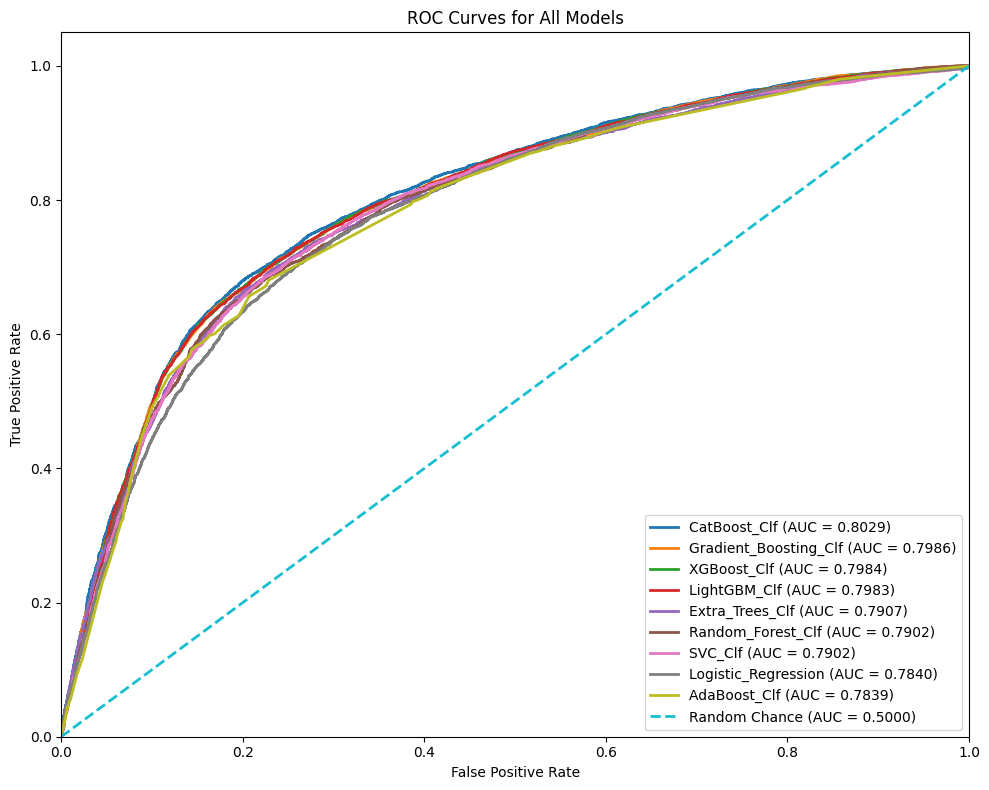

In [20]:
plt.figure(figsize=(10, 8))

for name in combined_results_df['Model']:
    y_score = y_score_store[name]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Chance (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('cardio_roc_auc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## PR-AUC plot 

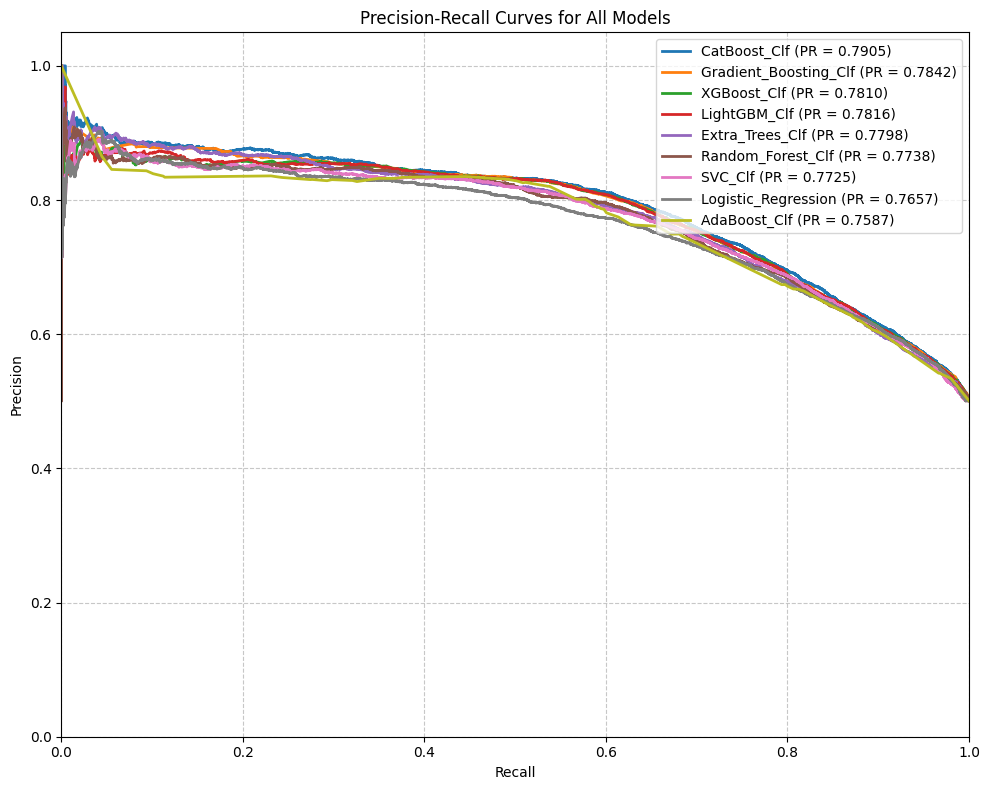

In [21]:
plt.figure(figsize=(10, 8))

for name in combined_results_df['Model']:
    y_score = y_score_store[name]
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, lw=2, label=f'{name} (PR = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for All Models')
plt.legend(loc='upper right')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('cardio_pr_auc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Confusion matrices for the nine models

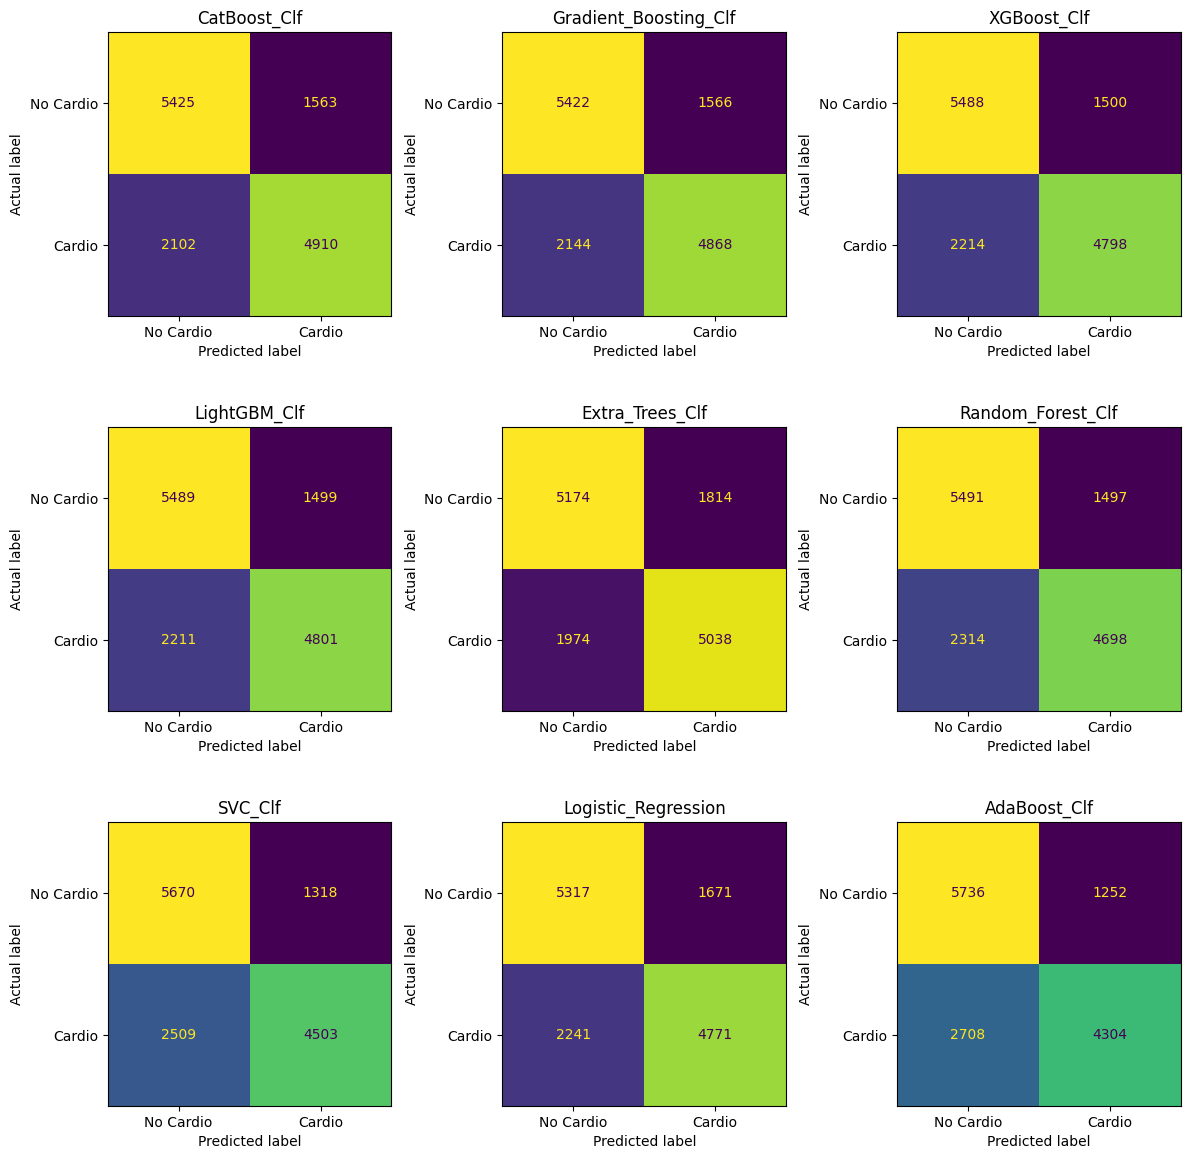

In [22]:
class_names = ['No Cardio', 'Cardio']

plt.figure(figsize=(12, 12))
for idx, name in enumerate(combined_results_df['Model']):
    plt.subplot(3, 3, idx + 1)
    cm = confusion_matrix(y_test, y_pred_store[name], labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=plt.gca(), colorbar=False)
    plt.title(name)
    plt.xlabel('Predicted label')
    plt.ylabel('Actual label')

plt.tight_layout()
plt.savefig('cardio_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Compact table for the performance evaluation and fault metrics

In [23]:
requested_metric_columns = [
    'Model',
    'Testing_Accuracy',
    'Recall',
    'Precision',
    'Specificity',
    'F1_Score',
    'ROC_AUC',
    'PR_AUC',
    'FPR',
    'FNR',
    'FOR',
    'FDR'
]

requested_metrics_df = combined_results_df[requested_metric_columns].copy()
display(requested_metrics_df.round(4))
requested_metrics_df.to_csv('cardio_requested_testing_and_fault_metrics.csv', index=False)
print('Saved: cardio_requested_testing_and_fault_metrics.csv')

,Model,Testing_Accuracy,Recall,Precision,Specificity,F1_Score,ROC_AUC,PR_AUC,FPR,FNR,FOR,FDR
0,CatBoost_Clf,0.7382,0.7002,0.7585,0.7763,0.7282,0.8029,0.7905,0.2237,0.2998,0.2793,0.2415
1,Gradient_Boosting_Clf,0.7350,0.6942,0.7566,0.7759,0.7241,0.7986,0.7842,0.2241,0.3058,0.2834,0.2434
2,XGBoost_Clf,0.7347,0.6843,0.7618,0.7853,0.7210,0.7984,0.7810,0.2147,0.3157,0.2875,0.2382
3,LightGBM_Clf,0.7350,0.6847,0.7621,0.7855,0.7213,0.7983,0.7816,0.2145,0.3153,0.2871,0.2379
4,Extra_Trees_Clf,0.7294,0.7185,0.7353,0.7404,0.7268,0.7907,0.7798,0.2596,0.2815,0.2762,0.2647
5,Random_Forest_Clf,0.7278,0.6700,0.7584,0.7858,0.7114,0.7902,0.7738,0.2142,0.3300,0.2965,0.2416
6,SVC_Clf,0.7266,0.6422,0.7736,0.8114,0.7018,0.7902,0.7725,0.1886,0.3578,0.3068,0.2264
7,Logistic_Regression,0.7206,0.6804,0.7406,0.7609,0.7092,0.7840,0.7657,0.2391,0.3196,0.2965,0.2594
8,AdaBoost_Clf,0.7171,0.6138,0.7747,0.8208,0.6849,0.7839,0.7587,0.1792,0.3862,0.3207,0.2253


Saved: cardio_requested_testing_and_fault_metrics.csv


## Additional validation analysis: model ranking and generalization gap

A small gap between cross-validated training performance and independent testing performance suggests more stable generalization. A large positive gap may indicate optimism in cross-validation or instability across the split.

In [24]:
ranking_columns = [
    'Model',
    'ROC_AUC',
    'PR_AUC',
    'Testing_Accuracy',
    'CV_accuracy_Mean',
    'CV_accuracy_SD',
    'Accuracy_Generalization_Gap',
    'Balanced_Accuracy',
    'MCC',
    'Brier_Score'
]

ranking_df = combined_results_df[ranking_columns].copy()
display(ranking_df.round(4))

best_model_name = ranking_df.iloc[0]['Model']
print(f"Best model by ROC-AUC, with PR-AUC as secondary ranking criterion: {best_model_name}")

,Model,ROC_AUC,PR_AUC,Testing_Accuracy,CV_accuracy_Mean,CV_accuracy_SD,Accuracy_Generalization_Gap,Balanced_Accuracy,MCC,Brier_Score
0,CatBoost_Clf,0.8029,0.7905,0.7382,0.7339,0.0031,-0.0043,0.7383,0.4779,0.1798
1,Gradient_Boosting_Clf,0.7986,0.7842,0.7350,0.7308,0.0046,-0.0042,0.7351,0.4717,0.1832
2,XGBoost_Clf,0.7984,0.7810,0.7347,0.7311,0.0035,-0.0037,0.7348,0.4720,0.1822
3,LightGBM_Clf,0.7983,0.7816,0.7350,0.7299,0.0035,-0.0051,0.7351,0.4725,0.1823
4,Extra_Trees_Clf,0.7907,0.7798,0.7294,0.7260,0.0023,-0.0034,0.7294,0.4590,0.1860
5,Random_Forest_Clf,0.7902,0.7738,0.7278,0.7252,0.0048,-0.0025,0.7279,0.4588,0.1921
6,SVC_Clf,0.7902,0.7725,0.7266,0.7220,0.0035,-0.0046,0.7268,0.4601,0.1912
7,Logistic_Regression,0.7840,0.7657,0.7206,0.7158,0.0021,-0.0048,0.7206,0.4427,0.1928
8,AdaBoost_Clf,0.7839,0.7587,0.7171,0.7146,0.0049,-0.0026,0.7173,0.4442,0.1932


Best model by ROC-AUC, with PR-AUC as secondary ranking criterion: CatBoost_Clf


## Fault Metrics Plot

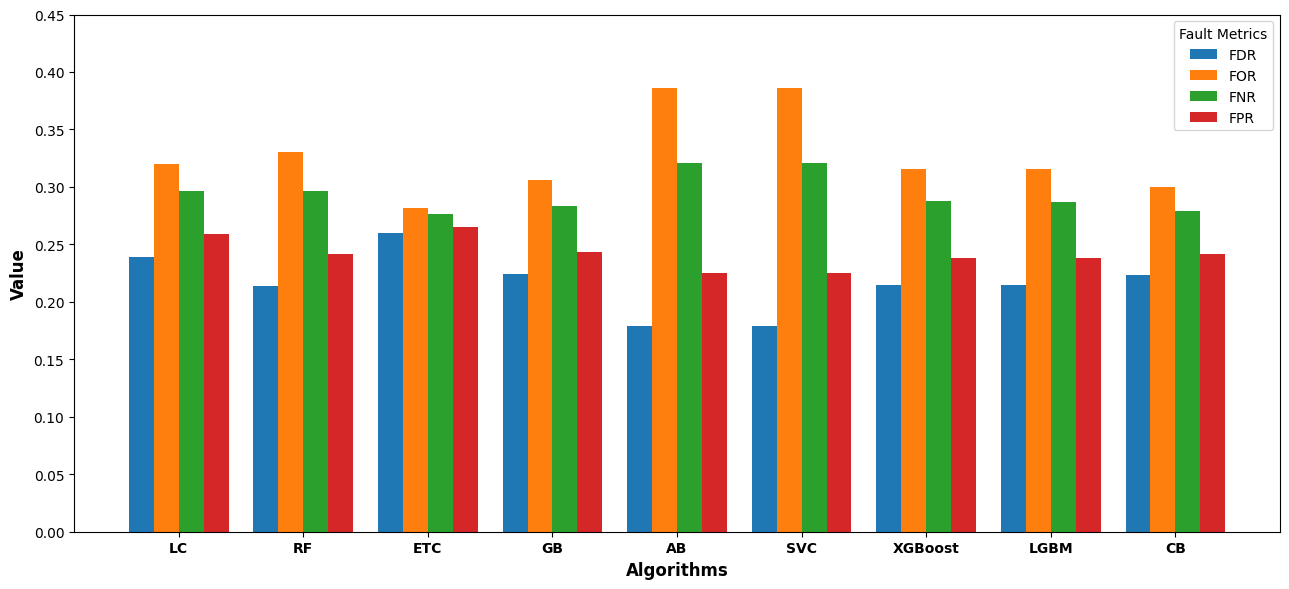

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {
    'Algorithms': ['LC', 'RF', 'ETC', 'GB', 'AB', 'SVC', 'XGBoost', 'LGBM', 'CB'],
    'FDR': [0.2391, 0.2142, 0.2596, 0.2241, 0.1792, 0.1792, 0.2147, 0.2145, 0.2237],
    'FOR': [0.3196, 0.3300, 0.2815, 0.3058, 0.3862, 0.3862, 0.3157, 0.3153, 0.2998],
    'FNR': [0.2965, 0.2965, 0.2762, 0.2834, 0.3207, 0.3207, 0.2875, 0.2871, 0.2793],
    'FPR': [0.2594, 0.2416, 0.2647, 0.2434, 0.2253, 0.2253, 0.2382, 0.2379, 0.2415]
}

df = pd.DataFrame(data)

# Metrics to plot
metrics_to_plot = ['FDR', 'FOR', 'FNR', 'FPR']

# X-axis positions
x = np.arange(len(df['Algorithms']))

# Width of each bar
bar_width = 0.20

# Plotting
fig, ax = plt.subplots(figsize=(13, 6))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(
        x + i * bar_width,
        df[metric],
        width=bar_width,
        label=metric
    )

# Adding labels
ax.set_xlabel('Algorithms', fontweight='bold', fontsize=12)
ax.set_ylabel('Value', fontweight='bold', fontsize=12)

# Center x-axis labels
ax.set_xticks(x + bar_width * (len(metrics_to_plot) - 1) / 2)
ax.set_xticklabels(df['Algorithms'], fontweight='bold')

# Formatting
ax.set_ylim(0, 0.45)
ax.legend(title='Fault Metrics')
plt.tight_layout()

# Show plot
plt.show()